## MScFE652 Portfolio Management GWP3
Group 11585


In [ ]:
import pandas as pd
import numpy as np
import cvxpy as cp
from itertools import combinations
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm, t, skew, kurtosis
from scipy.spatial.distance import squareform, pdist
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list, fcluster
from statsmodels.tsa.stattools import adfuller
from sklearn.covariance import LedoitWolf
from sklearn import cluster

import pymc as pm
import arviz as az
import pytensor.tensor as pt

import warnings
warnings.filterwarnings('ignore')

#### Data and EDA
We downloaded daily close price data from Yahoo Finance (using *yf* package) from 2024/01/01 to 2025/07/31 (a total of 393 data points) for the following 12 tickers from a diverse range of sectors. We then transformed the daily prices  into daily (simple) returns.
* MSFT: Microsoft
* NVDA: NVidia
* META: Meta
* GOOGL: Alphabet,
* JPM: JPMorgan Chase
* BAC: Bank of America
* LNC: Lincon Life Insurance
* HCI: HCI P&C insurance
* JNJ: Johnson & Johnson
* LLY: Eli Lilly
* PFE: Pfizer
* XOM: XOM Energy

In [ ]:
# Load 12 tickers daily (close) price; convert to daily return
tickers = ['MSFT', 'NVDA', 'META','GOOGL', 'JPM','BAC','LNC','HCI','JNJ','LLY', 'PFE', 'XOM']
start_date = '2024-01-01'
end_date = '2025-07-30'

data = {}
for ticker in tickers:
    df_ticker = yf.download(ticker, start=start_date, end=end_date, auto_adjust=False, back_adjust=False)[['Close']]
    data[ticker] = df_ticker

df = pd.concat(data, axis=1)
df.columns = tickers
df = df.pct_change().dropna()
df.info()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 393 entries, 2024-01-03 to 2025-07-29
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   MSFT    393 non-null    float64
 1   NVDA    393 non-null    float64
 2   META    393 non-null    float64
 3   GOOGL   393 non-null    float64
 4   JPM     393 non-null    float64
 5   BAC     393 non-null    float64
 6   LNC     393 non-null    float64
 7   HCI     393 non-null    float64
 8   JNJ     393 non-null    float64
 9   LLY     393 non-null    float64
 10  PFE     393 non-null    float64
 11  XOM     393 non-null    float64
dtypes: float64(12)
memory usage: 39.9 KB


The data is further split into training (from 2024/01/01 to 2025/06/30) and testing (from 2025/07/01 to 2025/07/31).

In [ ]:
# Training data (up to 2025/06/30)
df_train = df.loc[:'2025-06-30']
df_train.tail()

,MSFT,NVDA,META,GOOGL,JPM,BAC,LNC,HCI,JNJ,LLY,PFE,XOM
Date,,,,,,,,,,,,
2025-06-24,0.008457,0.025872,0.019570,0.009565,0.010745,0.007775,0.010055,-0.000468,0.005749,0.009654,0.011652,-0.030428
2025-06-25,0.004407,0.043340,-0.004942,0.023445,0.009955,0.004072,-0.006637,-0.004955,0.000591,0.018276,-0.002057,0.000277
2025-06-26,0.010523,0.004601,0.024567,0.016757,0.016511,0.013020,0.048284,0.013121,-0.001773,0.003559,-0.000824,0.014949
2025-06-27,-0.003036,0.017611,0.010384,0.028754,-0.005680,-0.007164,0.001448,0.003453,0.002631,-0.024738,-0.002063,-0.005546
2025-06-30,0.002964,0.001521,0.006079,-0.012883,0.009752,0.004244,0.000868,0.007347,0.002231,0.005261,0.002067,-0.014445


In [ ]:
# Testing data (after 2025/06/30)
df_test = df.loc['2025-07-01':]
df_test.tail()

,MSFT,NVDA,META,GOOGL,JPM,BAC,LNC,HCI,JNJ,LLY,PFE,XOM
Date,,,,,,,,,,,,
2025-07-23,0.001187,0.022451,0.012443,-0.005801,0.018289,0.007745,0.022029,-0.007277,0.006967,0.028914,0.008751,0.012806
2025-07-24,0.009904,0.017332,0.001710,0.010198,-0.000708,0.005193,-0.015315,-0.020369,0.002720,0.008186,-0.000394,0.007823
2025-07-25,0.005539,-0.001381,-0.002966,0.005256,0.006980,0.001240,0.003168,-0.004964,-0.007431,0.009014,-0.022091,-0.003520
2025-07-28,-0.002355,0.018732,0.006946,-0.003106,-0.001139,-0.004541,0.006891,-0.000868,-0.012359,-0.005636,-0.019363,0.009420
2025-07-29,0.000137,-0.007016,-0.024567,0.016461,-0.004157,-0.005805,-0.000855,0.000941,0.011370,-0.055883,-0.000411,0.012922


We performed Exploratory Data Analysis with the following observations:
* Most Tech stocks show positive skewness, but also high volatility and positive excess kurtosis, while some healthcare and energy stocks have negative or neutral sknewness and low positive excess kurtosis.
* The Augmented Dick-Fuller tests of daily returns are stationary.
- The correlations between assets are positive in general; the correlations between Tech stocks and between Financial stocks are quite high, while the rest of stocks are much lower - reflecting the diversification benefit of these "defensive" stocks.

In [ ]:
# descriptive statistics, normality test, and ADF test results
eda_df = []
for col in df_train.columns:
    mean = df[col].mean()
    std = df[col].std()
    skewness = skew(df[col])
    kurt = kurtosis(df[col])
    adf_result = adfuller(df[col].dropna())
    adf_statistic = f"{adf_result[0]:.4f}"
    p_value_adf = f"{adf_result[1]:.4f}"
    is_stationary = "Stationary" if adf_result[1] <= 0.01 else "Non-stationary"

    eda_df.append({
        "Asset": col,
        "Mean": f"{mean:.4f}",
        "Std": f"{std:.4f}",
        "Skewness": f"{skewness:.4f}",
        "Kurtosis": f"{kurt:.4f}",
        "ADF p-value": p_value_adf,
        "Stationary (p<=0.01)?": is_stationary
    })

eda_df = pd.DataFrame(eda_df)
eda_df

,Asset,Mean,Std,Skewness,Kurtosis,ADF p-value,Stationary (p<=0.01)?
0,MSFT,0.0009,0.0145,0.5764,8.3754,0.0000,Stationary
1,NVDA,0.0039,0.0346,0.1453,4.4558,0.0000,Stationary
2,META,0.0021,0.0240,1.6279,16.3719,0.0000,Stationary
3,GOOGL,0.0011,0.0191,0.0485,4.5329,0.0000,Stationary
4,JPM,0.0015,0.0159,0.1548,11.0415,0.0000,Stationary
5,BAC,0.0010,0.0164,-0.6460,8.6400,0.0000,Stationary
6,LNC,0.0009,0.0241,0.0036,7.2729,0.0000,Stationary
7,HCI,0.0014,0.0237,-0.2393,11.3743,0.0000,Stationary
8,JNJ,0.0002,0.0115,-0.2065,7.4215,0.0000,Stationary
9,LLY,0.0009,0.0221,0.1669,6.7913,0.0000,Stationary


In [ ]:
# func to calculate maximum drawdown
def max_drawdown(returns):
    cumulative_returns = (1 + returns).cumprod()
    peak = cumulative_returns.expanding(min_periods=1).max()
    drawdown = (cumulative_returns - peak) / peak
    max_drawdown = drawdown.min()
    return max_drawdown
# func to calculate VaR
def historical_var(returns, level=0.05):
    return np.percentile(returns, level * 100)

#### Baseline: Markowitz MVO (Mean-Variance Optimization)
Calculate the optimal portfolio weights for Maxmimal Sharpe ratio with no  short selling, positive weights and less than 15% of total portfolio.

In [ ]:
# func to derive efficient fronter: portfolio weights for minimum portfolio variance given target return
def func_mvo(mu, cov, rf, n_assets):
  port_weights, port_rets, port_vols, port_sharpes = [], [], [], []
  for rp_target in rp_targets:
    w = cp.Variable(n_assets)
    port_ret =  mu @ w
    port_var = cp.quad_form(w, cov)
    obj = cp.Minimize(port_var)
    constraints = [
        port_ret >= rp_target,
        cp.sum(w) == 1,
        w >= 0,
        w <= 0.15]
    problem = cp.Problem(obj, constraints)
    problem.solve()
    # print(f'target return: {rp_target}; port var: {port_var.value}; weights: {w.value};')

    if (w.value is None):
      pass
    else:
      port_vol = np.sqrt(port_var.value)
      port_weights.append(w.value)
      port_rets.append(port_ret.value)
      port_vols.append(port_vol)
      port_sharpes.append((port_ret.value - rf)/port_vol)

  return port_weights, port_rets, port_vols, port_sharpes

In [ ]:
n_assets = len(tickers)
mu_raw = df_train.mean().values
vol_raw = df_train.std().values
cov_raw = df_train.cov().values
rf = 0.0002
rp_targets=np.arange(min(mu_raw),max(mu_raw),0.000025)


Maximal Sharpe ratio portfolio (constrained):
Portfolio return: 0.164%
Portfolio volatility: 1.209%
Sharpe ratio: 11.918%


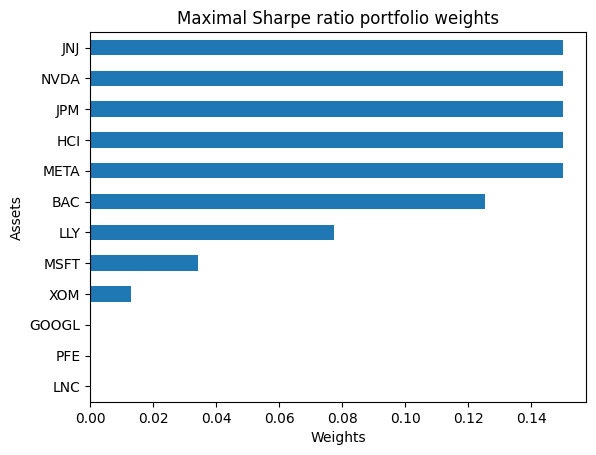

In [ ]:
port_weights, port_rets, port_vols, port_sharpes = func_mvo(mu_raw, cov_raw, rf, n_assets)
max_sharpe_idx = np.argmax(port_sharpes)
max_sharpe_ret = port_rets[max_sharpe_idx]
max_sharpe_vol = port_vols[max_sharpe_idx]
max_sharpe_ratio = port_sharpes[max_sharpe_idx]
max_sharpe_weights = port_weights[max_sharpe_idx]

print(f"\nMaximal Sharpe ratio portfolio (constrained):")
print(f"Portfolio return: {max_sharpe_ret:.3%}")
print(f"Portfolio volatility: {max_sharpe_vol:.3%}")
print(f"Sharpe ratio: {max_sharpe_ratio:.3%}")

pd.Series(max_sharpe_weights, tickers).sort_values().plot(kind='barh')
plt.title('Maximal Sharpe ratio portfolio weights')
plt.xlabel('Weights')
plt.ylabel('Assets');

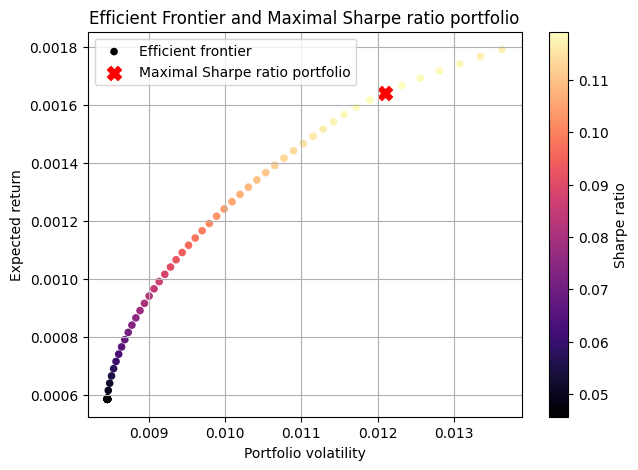

In [ ]:
# efficient frontier and the minimal Sharpe ratio portfolio
plt.figure(figsize=(7, 5))

plt.scatter(port_vols, port_rets, c=port_sharpes, cmap='magma',s=20, label='Efficient frontier')
plt.colorbar(label='Sharpe ratio')
plt.scatter(max_sharpe_vol, max_sharpe_ret, color='red', marker='X', s=100, label='Maximal Sharpe ratio portfolio')
plt.title('Efficient Frontier and Maximal Sharpe ratio portfolio')
plt.xlabel('Portfolio volatility')
plt.ylabel('Expected return')
plt.legend()
plt.grid(True)
plt.show()

Testing data performance Maximal Sharpe ratio portfolio
Test data performance of the Maximal Sharpe ratio portfolio:

Average daily return: 0.076%
Daily volatility: 0.611%
Sharpe ratio: 9.115%
Maximum drawdown: -1.529%
VaR at 95%: -0.842%


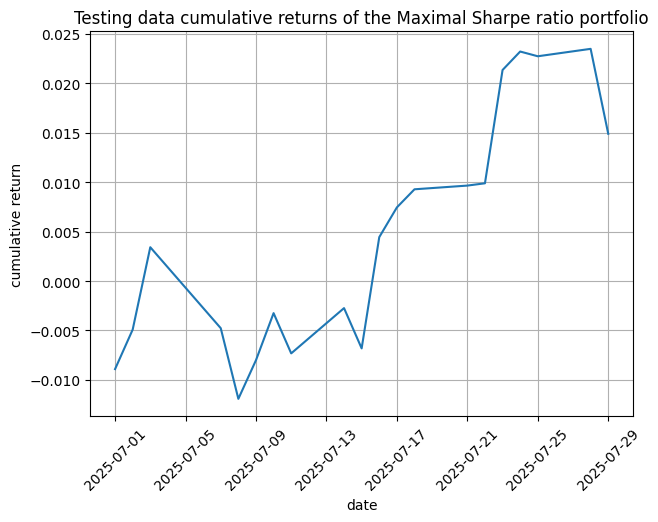

In [ ]:
# Testing data performance for the Maximal Sharpe ratio portfolio
print("Testing data performance Maximal Sharpe ratio portfolio")
test_rets = (df_test[tickers] @ max_sharpe_weights)
test_avg_ret = test_rets.mean()
test_vol = test_rets.std()
test_sharpe = (test_avg_ret - rf) / test_vol
test_max_drawdown = max_drawdown(test_rets)
test_var_95 = historical_var(test_rets, level=0.05)

print("Test data performance of the Maximal Sharpe ratio portfolio:\n")
print(f"Average daily return: {test_avg_ret:.3%}")
print(f"Daily volatility: {test_vol:.3%}")
print(f"Sharpe ratio: {test_sharpe:.3%}")
print(f"Maximum drawdown: {test_max_drawdown:.3%}")
print(f"VaR at 95%: {test_var_95:.3%}")

# plot cumulative returns
cumulative_rets = (1 + test_rets).cumprod() - 1
plt.figure(figsize=(7, 5))
plt.plot(cumulative_rets)
plt.title('Testing data cumulative returns of the Maximal Sharpe ratio portfolio')
plt.xlabel('date')
plt.ylabel('cumulative return')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

#### Improvements using denoising

###### Ledoit-Wolf Shrinkage covariance matrix

In [ ]:
model_LW = LedoitWolf()
# fit LW model to the training covariance matrix
cov_LW = model_LW.fit(df_train).covariance_

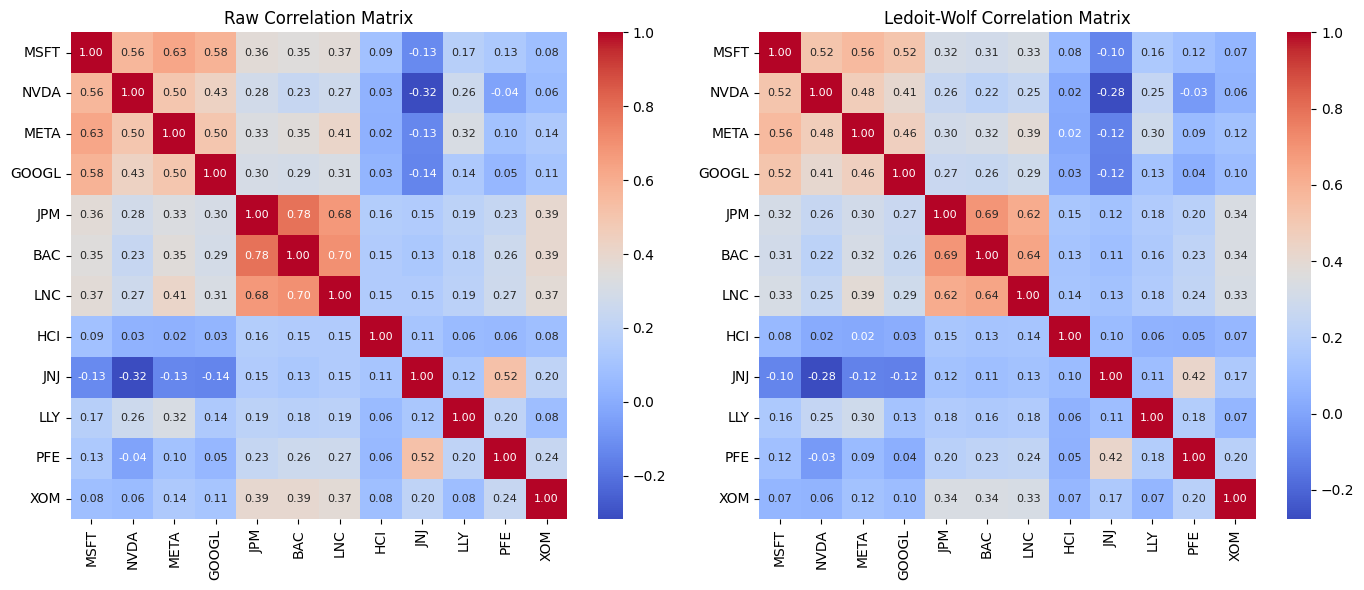

In [ ]:
corr_matrix_raw = df_train.corr()
D = np.diag(1 / np.sqrt(np.diag(cov_LW)))
corr_matrix_lw = D @ cov_LW @ D
corr_matrix_lw = pd.DataFrame(corr_matrix_lw, index=df_train.columns, columns=df_train.columns)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.heatmap(corr_matrix_raw, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 8})
plt.title('Raw Correlation Matrix')

plt.subplot(1, 2, 2)
sns.heatmap(corr_matrix_lw, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 8})
plt.title('Ledoit-Wolf Correlation Matrix')

plt.tight_layout()
plt.show()


Maximal Sharpe ratio portfolio (Ledoit-Wolf):
Portfolio return: 0.164%
Portfolio volatility: 1.181%
Sharpe ratio: 12.209%


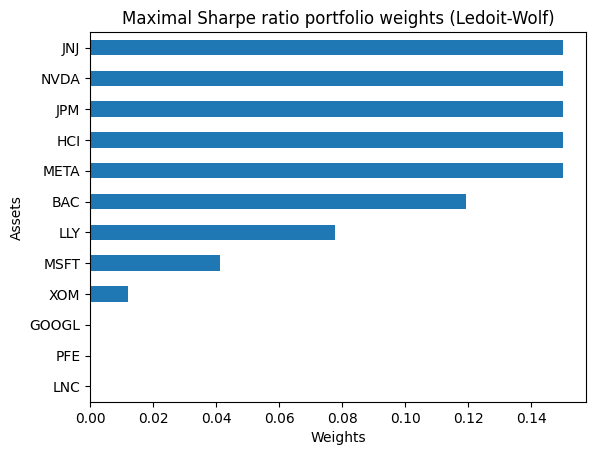

In [ ]:
port_weights_LW, port_rets_LW, port_vols_LW, port_sharpes_LW = func_mvo(mu_raw, cov_LW, rf, n_assets)
max_sharpe_idx_LW = np.argmax(port_sharpes_LW)
max_sharpe_ret_LW = port_rets_LW[max_sharpe_idx_LW]
max_sharpe_vol_LW = port_vols_LW[max_sharpe_idx_LW]
max_sharpe_ratio_LW = port_sharpes_LW[max_sharpe_idx_LW]
max_sharpe_weights_LW = port_weights_LW[max_sharpe_idx_LW]

print(f"\nMaximal Sharpe ratio portfolio (Ledoit-Wolf):")
print(f"Portfolio return: {max_sharpe_ret_LW:.3%}")
print(f"Portfolio volatility: {max_sharpe_vol_LW:.3%}")
print(f"Sharpe ratio: {max_sharpe_ratio_LW:.3%}")

pd.Series(max_sharpe_weights_LW, tickers).sort_values().plot(kind='barh')
plt.title('Maximal Sharpe ratio portfolio weights (Ledoit-Wolf)')
plt.xlabel('Weights')
plt.ylabel('Assets')
plt.show()

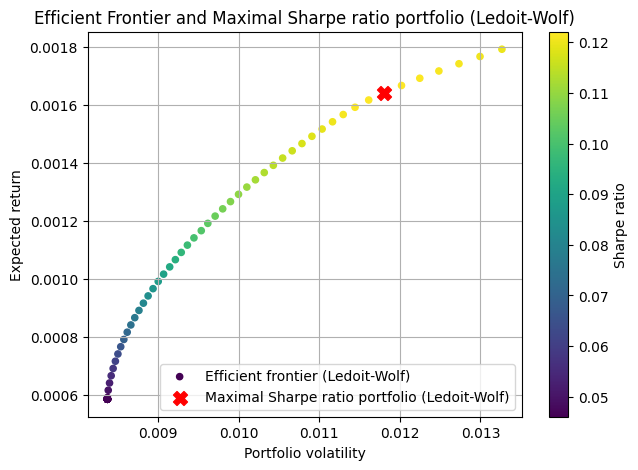

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(port_vols_LW, port_rets_LW, c=port_sharpes_LW, cmap='viridis', s=20, label='Efficient frontier (Ledoit-Wolf)')
plt.colorbar(label='Sharpe ratio')
plt.scatter(max_sharpe_vol_LW, max_sharpe_ret_LW, color='red', marker='X', s=100, label='Maximal Sharpe ratio portfolio (Ledoit-Wolf)')
plt.title('Efficient Frontier and Maximal Sharpe ratio portfolio (Ledoit-Wolf)')
plt.xlabel('Portfolio volatility')
plt.ylabel('Expected return')
plt.legend()
plt.grid(True)
plt.show()

Testing data performance Maximal Sharpe ratio portfolio Ledoit-Wolf
Test data performance of the Ledoit-Wolf Maximal Sharpe ratio portfolio:

Average daily return: 0.076%
Daily volatility: 0.611%
Sharpe ratio: 9.172%
Maximum drawdown: -1.512%
VaR at 95%: -0.843%


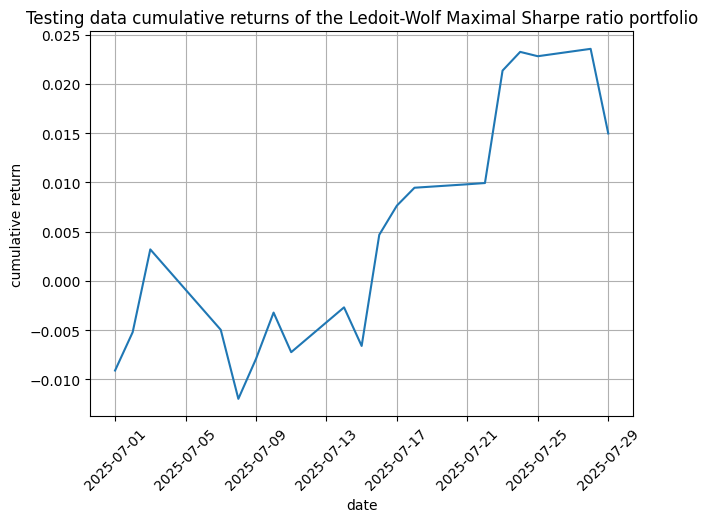

In [ ]:
# Testing data performance for the LW Maximal Sharpe ratio portfolio
print("Testing data performance Maximal Sharpe ratio portfolio Ledoit-Wolf")
test_rets_LW = (df_test[tickers] @ max_sharpe_weights_LW)
test_avg_ret_LW = test_rets_LW.mean()
test_vol_LW = test_rets_LW.std()
test_sharpe_LW = (test_avg_ret_LW - rf) / test_vol_LW
test_max_drawdown_LW = max_drawdown(test_rets_LW)
test_var_95_LW = historical_var(test_rets_LW, level=0.05)

print("Test data performance of the Ledoit-Wolf Maximal Sharpe ratio portfolio:\n")
print(f"Average daily return: {test_avg_ret_LW:.3%}")
print(f"Daily volatility: {test_vol_LW:.3%}")
print(f"Sharpe ratio: {test_sharpe_LW:.3%}")
print(f"Maximum drawdown: {test_max_drawdown_LW:.3%}")
print(f"VaR at 95%: {test_var_95_LW:.3%}")

# plot cumulative returns
cumulative_rets_LW = (1 + test_rets_LW).cumprod() - 1
plt.figure(figsize=(7, 5))
plt.plot(cumulative_rets_LW)
plt.xticks(rotation=45)
plt.title('Testing data cumulative returns of the Ledoit-Wolf Maximal Sharpe ratio portfolio')
plt.xlabel('date')
plt.ylabel('cumulative return')
plt.grid(True)
plt.show()

In [ ]:
# simplified Combinatory Purged Cross Validation (CPCV) function
def cpcv_splits(df, n_folds=5, n_test_folds=2):
    n_obs = len(df)
    fold_size = n_obs // n_folds
    folds = [(i * fold_size, i * fold_size + fold_size if i < n_folds - 1 else n_obs) for i in range(n_folds)]

    df_list = []
    for test_fold_ids in combinations(range(n_folds), n_test_folds):
        test_idx = [idx for fold_id in test_fold_ids for idx in range(folds[fold_id][0], folds[fold_id][1])]
        train_fold_ids = set(range(n_folds)) - set(test_fold_ids)
        train_idx = [idx for fold_id in train_fold_ids for idx in range(folds[fold_id][0], folds[fold_id][1])]
        df_list.append({'train': df.iloc[train_idx], 'test':df.iloc[test_idx]})

    return df_list

    df_cpcv_list=cpcv_splits(df_train)

In [ ]:
df_cpcv_list=cpcv_splits(df_train)

In [ ]:
alpha_range = np.linspace(0, 1, 41) # Define a range of alpha values from 0 to 1
optimal_alphas_per_fold = []

for fold_id, fold in enumerate(df_cpcv_list):
    df_train_fold = fold['train']
    df_test_fold = fold['test']

    mu_raw_fold = df_train_fold.mean().values
    cov_raw_fold = df_train_fold.cov().values

    mu_test_fold = df_test_fold.mean().values
    cov_test_fold = df_test_fold.cov().values

    best_sharpe_ratio_fold = -np.inf
    optimal_alpha_fold = None

    for alpha in alpha_range:
        # EPO Covariance matrix
        shrunk_cov = cov_raw_fold * (1 - alpha) + np.diag(np.diag(cov_raw_fold)) * alpha

        # Use func_mvo to find maximal Sharpe ratio portfolio weights on training data
        port_weights_shrunk, port_rets_shrunk, port_vols_shrunk, port_sharpes_shrunk = func_mvo(mu_raw_fold, shrunk_cov, rf, n_assets)

        if len(port_sharpes_shrunk) > 0: # Ensure there are valid portfolios
            max_sharpe_idx_shrunk = np.argmax(port_sharpes_shrunk)
            max_sharpe_weights_shrunk = port_weights_shrunk[max_sharpe_idx_shrunk]

            # Evaluate Sharpe ratio using out-of-sample test data
            test_port_ret = mu_test_fold @ max_sharpe_weights_shrunk
            test_port_var = max_sharpe_weights_shrunk.T @ cov_test_fold @ max_sharpe_weights_shrunk
            test_port_vol = np.sqrt(test_port_var)

            # Avoid division by zero for Sharpe ratio calculation
            if test_port_vol > 0:
                test_sharpe_ratio = (test_port_ret - rf) / test_port_vol
            else:
                test_sharpe_ratio = -np.inf # Assign a very small value if volatility is zero

            if test_sharpe_ratio > best_sharpe_ratio_fold:
                best_sharpe_ratio_fold = test_sharpe_ratio
                optimal_alpha_fold = alpha

    print(f"For fold {fold_id}: optimal shrinkage is {optimal_alpha_fold:.2f};")

    # Append the optimal alpha for the current fold
    if optimal_alpha_fold is not None:
        optimal_alphas_per_fold.append(optimal_alpha_fold)
    else:
        # Handle cases where no optimal alpha was found (e.g., all Sharpe ratios were -inf)
        optimal_alphas_per_fold.append(0) # Default to 0 (raw covariance) if no better alpha is found


For fold 0: optimal shrinkage is 0.00;
For fold 1: optimal shrinkage is 0.18;
For fold 2: optimal shrinkage is 0.00;
For fold 3: optimal shrinkage is 0.00;
For fold 4: optimal shrinkage is 1.00;
For fold 5: optimal shrinkage is 0.93;
For fold 6: optimal shrinkage is 1.00;
For fold 7: optimal shrinkage is 0.00;
For fold 8: optimal shrinkage is 0.93;
For fold 9: optimal shrinkage is 0.00;


In [ ]:
# derive an optimal shrinkage - alpha based on the CPCV training/testing folds results above
aggregated_optimal_alpha = np.median(optimal_alphas_per_fold)
print(f"Aggregated optimal alpha: {aggregated_optimal_alpha:.2f}")
cov_epo = cov_raw * (1 - aggregated_optimal_alpha) + np.diag(np.diag(cov_raw)) * aggregated_optimal_alpha

Aggregated optimal alpha: 0.09


\EPO shrinkage Maximal Sharpe ratio portfolio:
Portfolio return: 0.164%
Portfolio volatility: 1.182%
Sharpe ratio: 12.197%


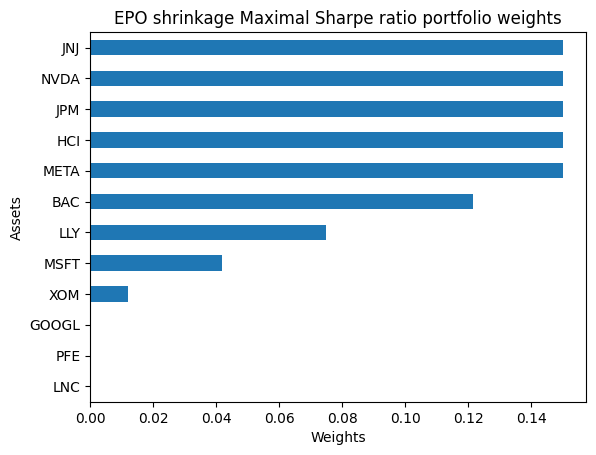

In [ ]:
# training data optimal results
port_weights_epo, port_rets_epo, port_vols_epo, port_sharpes_epo = func_mvo(mu_raw, cov_epo, rf, n_assets)
max_sharpe_idx_epo = np.argmax(port_sharpes_epo)
max_sharpe_ret_epo = port_rets_epo[max_sharpe_idx_epo]
max_sharpe_vol_epo = port_vols_epo[max_sharpe_idx_epo]
max_sharpe_ratio_epo = port_sharpes_epo[max_sharpe_idx_epo]
max_sharpe_weights_epo = port_weights_epo[max_sharpe_idx_epo]

print(f"\EPO shrinkage Maximal Sharpe ratio portfolio:")
print(f"Portfolio return: {max_sharpe_ret_epo:.3%}")
print(f"Portfolio volatility: {max_sharpe_vol_epo:.3%}")
print(f"Sharpe ratio: {max_sharpe_ratio_epo:.3%}")

pd.Series(max_sharpe_weights_epo, tickers).sort_values().plot(kind='barh')
plt.title('EPO shrinkage Maximal Sharpe ratio portfolio weights')
plt.xlabel('Weights')
plt.ylabel('Assets')
plt.show()

Testing data performance of the EPO optimal shrinkage Maximal Sharpe ratio portfolio
Test data performance of the EPO optimal shrinkage Maximal Sharpe ratio portfolio:

Average daily return: 0.077%
Daily volatility: 0.609%
Sharpe ratio: 9.294%
Maximum drawdown: -1.519%
VaR at 95%: -0.828%


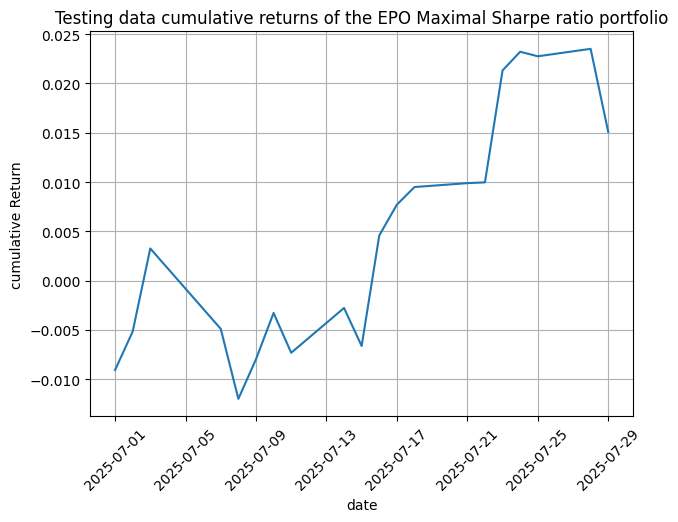

In [ ]:
# testing data performance for the EPO optimal shrinkage Maximal Sharpe ratio portfolio
print("Testing data performance of the EPO optimal shrinkage Maximal Sharpe ratio portfolio")
test_returns_epo = (df_test[tickers] @ max_sharpe_weights_epo)

# calculate test period performance
test_avg_ret_epo = test_returns_epo.mean()
test_vol_epo = test_returns_epo.std()
test_sharpe_epo = (test_avg_ret_epo - rf) / test_vol_epo
test_max_drawdown_epo = max_drawdown(test_returns_epo)
test_var_95_epo = historical_var(test_returns_epo, level=0.05)

print("Test data performance of the EPO optimal shrinkage Maximal Sharpe ratio portfolio:\n")
print(f"Average daily return: {test_avg_ret_epo:.3%}")
print(f"Daily volatility: {test_vol_epo:.3%}")
print(f"Sharpe ratio: {test_sharpe_epo:.3%}")
print(f"Maximum drawdown: {test_max_drawdown_epo:.3%}")
print(f"VaR at 95%: {test_var_95_epo:.3%}")

# plot cumulative returns
cumulative_rets_epo = (1 + test_returns_epo).cumprod() - 1
plt.figure(figsize=(7, 5))
plt.plot(cumulative_rets_epo)
plt.title('Testing data cumulative returns of the EPO Maximal Sharpe ratio portfolio')
plt.xlabel('date')
plt.ylabel('cumulative Return')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

###### Bayesian shrinkage approach - Multivariate Normal

In [ ]:
# Bayesian model for portfolio optimization
with pm.Model() as model_bayesian_normal:
  returns_data = pm.Data("returns_data",df_train)

  # mean returns with uncertainty
  mu = pm.Normal('mu', mu_raw, vol_raw * 0.5, shape = n_assets)

  # standard deviations of asset returns with uncertainty
  sigma = pm.HalfNormal.dist(vol_raw, shape = n_assets)

  # covariance matrix using LKJ prior
  chol, corr, _ = pm.LKJCholeskyCov("chol", n=n_assets, eta=1,sd_dist=sigma,compute_corr=True)
  corr_mat = pm.Deterministic("corr", corr)
  cov = pm.Deterministic('cov', chol.dot(chol.T))

 # weights sampling with constraints
  w_raw = pm.Dirichlet('w_raw',a=np.ones(n_assets))
  penalty_w = pm.math.sum(pm.math.maximum(0, w_raw - 0.15)**2)
  pm.Potential("weight_penalty", -100 * penalty_w)
  w = pm.Deterministic('w', w_raw)

  port_ret = pm.Deterministic('port_ret', w @ mu)
  port_vol = pm.Deterministic('port_vol', pt.sqrt(w.T @ cov @ w))
  port_sharpe = pm.Deterministic('port_sharpe', (port_ret - rf) / port_vol)
  pm.Potential("sharpe_maximization", 200*port_sharpe)

  obs = pm.MvNormal( "obs", mu = mu, chol=chol, observed= returns_data)

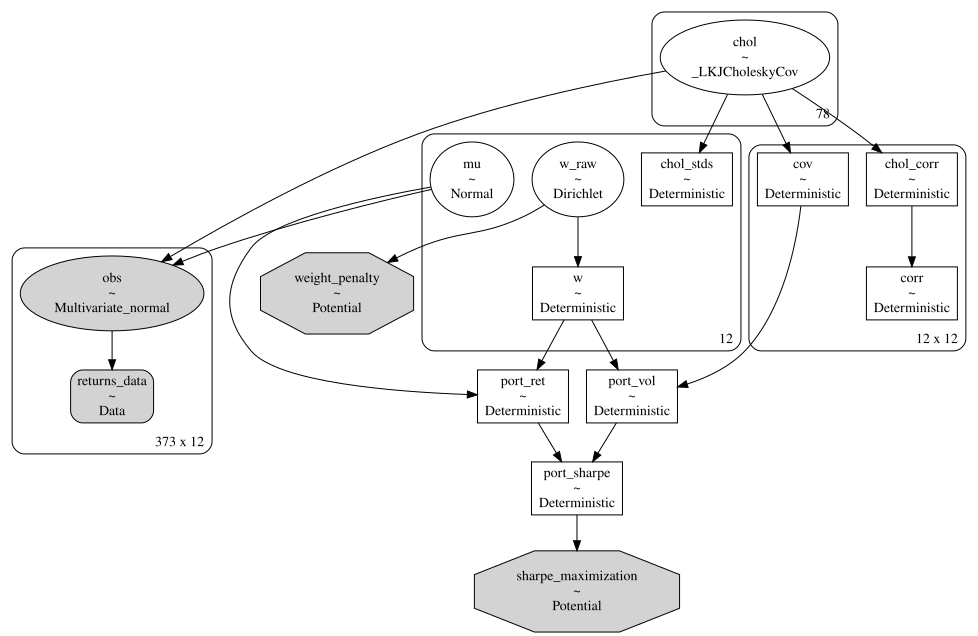

In [ ]:
pm.model_to_graphviz(model_bayesian_normal)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# az.to_netcdf(trace_normal,'/content/drive/MyDrive/Learning/WQU/PM/3/trace_normal.nc') # export results
# trace_normal = az.from_netcdf('/content/drive/MyDrive/Learning/WQU/PM/3/trace_normal.nc') # Load trace1 from the saved netCDF file

Mounted at /content/drive


'/content/drive/MyDrive/Learning/WQU/PM/3/trace_normal.nc'

In [ ]:
with model_bayesian_normal:
  trace_normal = pm.sample(return_inferencedata=True,posterior_predictive=True,draws=2000)

Output()

In [ ]:
az.summary(trace_normal,var_names=['w'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
w[0],0.062,0.051,0.000,0.156,0.001,0.001,2936.0,1997.0,1.0
w[1],0.175,0.057,0.056,0.274,0.001,0.001,2343.0,1736.0,1.0
w[2],0.111,0.066,0.002,0.223,0.001,0.001,2463.0,1734.0,1.0
w[3],0.054,0.046,0.000,0.139,0.001,0.001,1733.0,1254.0,1.0
w[4],0.105,0.067,0.000,0.216,0.001,0.001,1950.0,1405.0,1.0
w[5],0.070,0.054,0.000,0.168,0.001,0.001,2630.0,1765.0,1.0
w[6],0.043,0.039,0.000,0.115,0.001,0.001,2522.0,2075.0,1.0
w[7],0.145,0.065,0.017,0.254,0.001,0.001,1833.0,1735.0,1.0
w[8],0.068,0.054,0.000,0.167,0.001,0.001,2113.0,1361.0,1.0
w[9],0.067,0.051,0.000,0.159,0.001,0.001,1738.0,1583.0,1.0


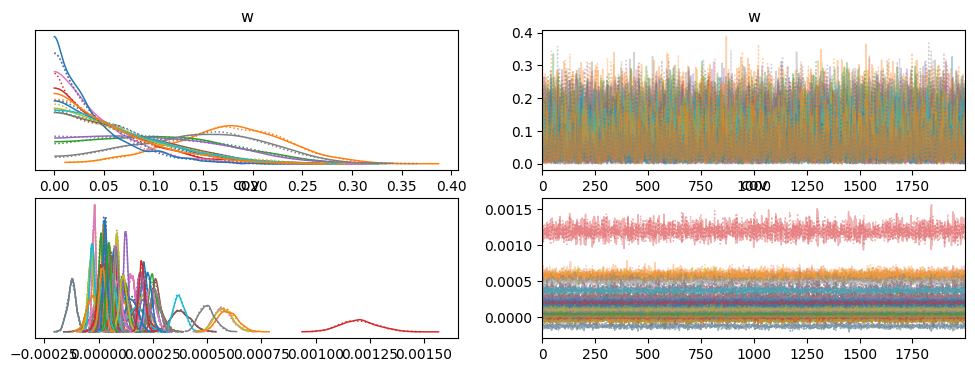

In [ ]:
az.plot_trace(trace_normal,var_names=['w','cov']);

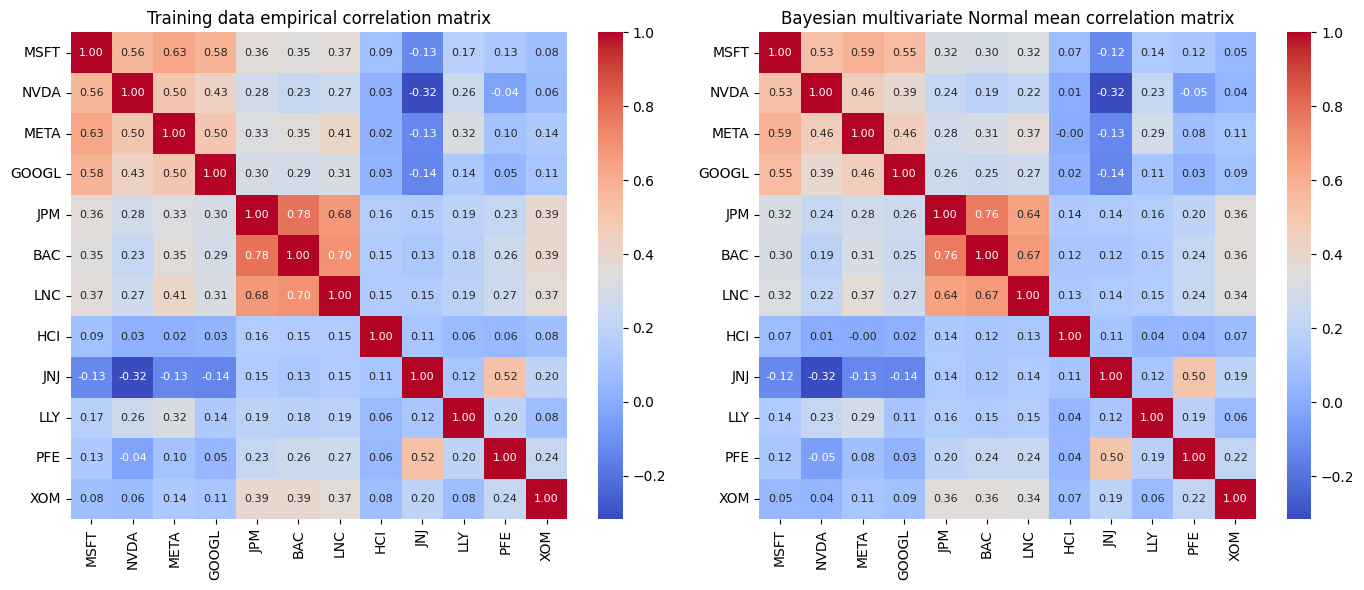

In [ ]:
# mean correlation matrix from the Bayesian model
corr_bayesian_mean = az.summary(trace_normal, var_names=['corr'])['mean'].values.reshape(n_assets, n_assets)

# Convert to DataFrame for easier plotting with seaborn and to apply asset names
df_corr_bayesian = pd.DataFrame(corr_bayesian_mean, index=tickers, columns=tickers)

raw_corr_df = df_train.corr()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.heatmap(raw_corr_df, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title('Training data empirical correlation matrix')

plt.subplot(1, 2, 2)
sns.heatmap(df_corr_bayesian, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title('Bayesian multivariate Normal mean correlation matrix')
plt.tight_layout()
plt.show()

In [ ]:
# to derive the optimal portfolio weights based on the Bayesian model results
# extract posterior samples
w_samples = trace_normal.posterior['w'].values.reshape(-1, n_assets)
sharpe_samples = trace_normal.posterior['port_sharpe'].values.reshape(-1)

# normalize sample Sharpe ratios to create weights (Sharpe ratio can be negative) to sum to one
sharpe_normalized = sharpe_samples - sharpe_samples.min()  # shift to positive
sharpe_weights = sharpe_normalized / sharpe_normalized.sum()  # normalize so that weights sum to 1

# Compute Sharpe ratio weighted portfolio weights
w_optimal = (w_samples.T * sharpe_weights).sum(axis=1)

<Figure size 700x500 with 0 Axes>

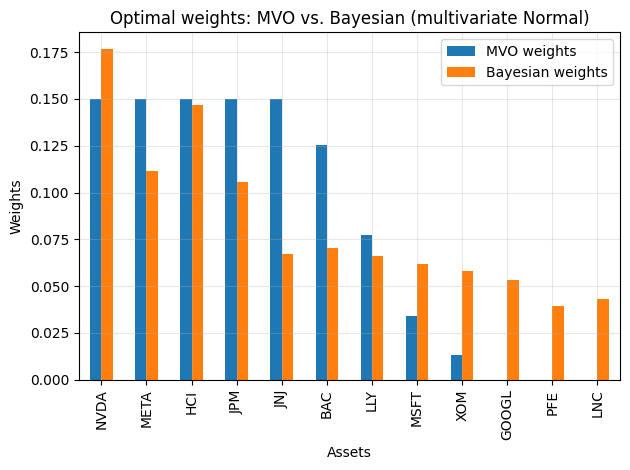

In [ ]:
mvo_weights = pd.Series(max_sharpe_weights, index=tickers, name='MVO weights')
bayesian_weights = pd.Series(w_optimal, index=tickers, name='Bayesian weights')

comparison_df = pd.DataFrame({'MVO weights': mvo_weights,'Bayesian weights': bayesian_weights})
comparison_df = comparison_df.sort_values(by='MVO weights', ascending=False)

# bar chart comparing the optimal weights
plt.figure(figsize=(7, 5))
comparison_df.plot(kind='bar', rot=90)
plt.title('Optimal weights: MVO vs. Bayesian (multivariate Normal)')
plt.xlabel('Assets')
plt.ylabel('Weights')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();

Testing data performance of the Bayesian Optimal portfolio
Test data performance of the Bayesian (multivariate Normal) Optimal portfolio:

Average daily return: 0.100%
Daily volatility: 0.541%
Sharpe ratio: 14.764%
Maximum drawdown: -1.125%
VaR at 95%: -0.901%


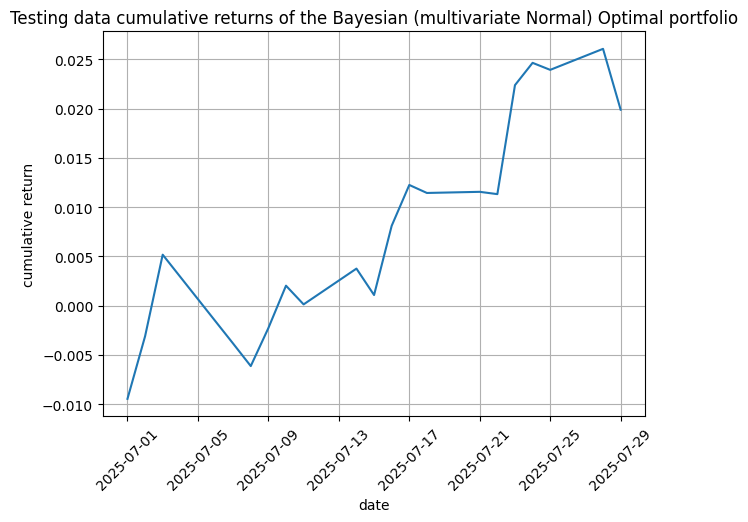

In [ ]:
# Testing data performance the Bayesian Optimal Portfolio
print("Testing data performance of the Bayesian Optimal portfolio")

test_returns_bayesian_normal = (df_test[tickers] @ w_optimal)
test_avg_ret_bayesian_normal = test_returns_bayesian_normal.mean()
test_vol_bayesian_normal = test_returns_bayesian_normal.std()
test_sharpe_bayesian_normal = (test_avg_ret_bayesian_normal - rf) / test_vol_bayesian_normal
test_max_drawdown_bayesian_normal = max_drawdown(test_returns_bayesian_normal)
test_var_95_bayesian_normal = historical_var(test_returns_bayesian_normal, level=0.05)

print("Test data performance of the Bayesian (multivariate Normal) Optimal portfolio:\n")
print(f"Average daily return: {test_avg_ret_bayesian_normal:.3%}")
print(f"Daily volatility: {test_vol_bayesian_normal:.3%}")
print(f"Sharpe ratio: {test_sharpe_bayesian_normal:.3%}")
print(f"Maximum drawdown: {test_max_drawdown_bayesian_normal:.3%}")
print(f"VaR at 95%: {test_var_95_bayesian_normal:.3%}")

# plot cumulative returns
cumulative_rets_bayesian_normal = (1 + test_returns_bayesian_normal).cumprod() - 1
plt.figure(figsize=(7, 5))
plt.plot(cumulative_rets_bayesian_normal)
plt.title('Testing data cumulative returns of the Bayesian (multivariate Normal) Optimal portfolio')
plt.xlabel('date')
plt.ylabel('cumulative return')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


###### Bayesian shrinkage approach - Multivariate Student-T

In [ ]:
# Bayesian model for portfolio optimization
with pm.Model() as model_bayesian_t:
  returns_data = pm.Data("returns_data",df_train)

  # d.o.f for student-T distribution (same for all asset returns for simplicity)
  nu = pm.Exponential('nu', 1/5)
  # mean returns with uncertainty
  mu = pm.Normal('mu', mu_raw, vol_raw * 0.5, shape = n_assets)

  # standard deviations of asset returns with uncertainty
  sigma = pm.HalfNormal.dist(vol_raw, shape = n_assets)

  # covariance matrix using LKJ prior
  chol, corr, _ = pm.LKJCholeskyCov("chol", n=n_assets, eta=1,sd_dist=sigma,compute_corr=True)
  corr_mat = pm.Deterministic("corr", corr)
  cov = pm.Deterministic('cov', chol.dot(chol.T))

 # weights sampling with constraints
  w_raw = pm.Dirichlet('w_raw',a=np.ones(n_assets))
  penalty_w = pm.math.sum(pm.math.maximum(0, w_raw - 0.15)**2)
  pm.Potential("weight_penalty", -100 * penalty_w)
  w = pm.Deterministic('w', w_raw)

  port_ret = pm.Deterministic('port_ret', w @ mu)
  port_vol = pm.Deterministic('port_vol', pt.sqrt(w.T @ cov @ w))
  port_sharpe = pm.Deterministic('port_sharpe', (port_ret - rf) / port_vol)
  pm.Potential("sharpe_maximization", 200*port_sharpe)

  obs = pm.MvStudentT( "obs", nu=nu, mu = mu, chol=chol, observed= returns_data)

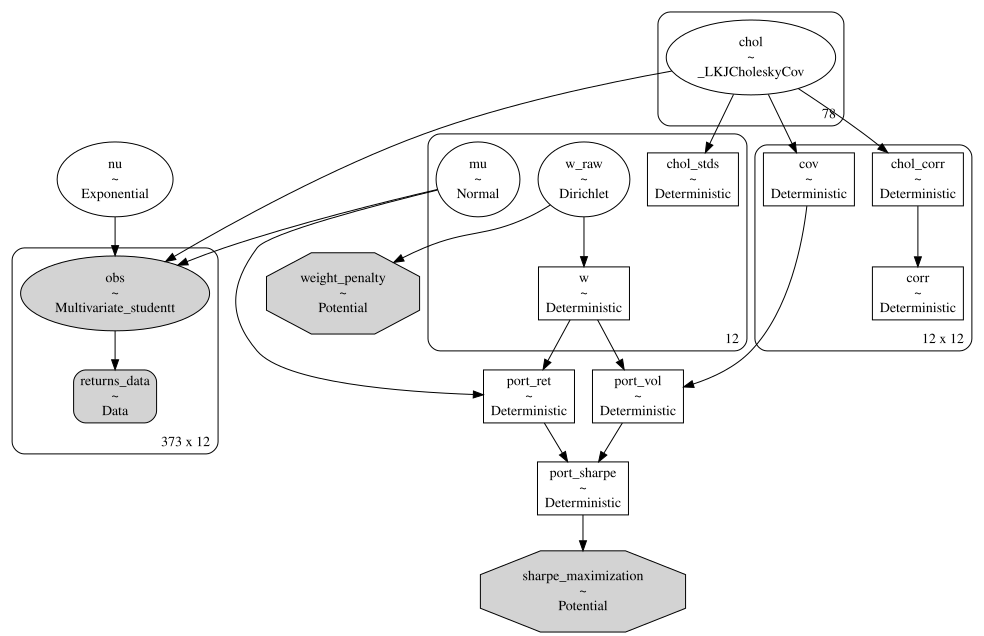

In [ ]:
pm.model_to_graphviz(model_bayesian_t)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# az.to_netcdf(trace_t,'/content/drive/MyDrive/Learning/WQU/PM/3/trace_t.nc') # export results
# trace_t = az.from_netcdf('/content/drive/MyDrive/Learning/WQU/PM/3/trace_t.nc') # Load trace1 from the saved netCDF file

'/content/drive/MyDrive/Learning/WQU/PM/3/trace_t.nc'

In [ ]:
with model_bayesian_t:
  trace_t = pm.sample(return_inferencedata=True,posterior_predictive=True,draws=2000)

Output()

In [ ]:
az.summary(trace_t,var_names=['nu','w'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
nu,4.944,0.478,4.045,5.838,0.010,0.009,2312.0,1911.0,1.0
w[0],0.067,0.051,0.000,0.162,0.001,0.001,2795.0,1956.0,1.0
w[1],0.130,0.051,0.035,0.225,0.001,0.001,1561.0,1088.0,1.0
w[2],0.076,0.053,0.000,0.170,0.001,0.001,1960.0,1642.0,1.0
w[3],0.054,0.042,0.000,0.131,0.001,0.001,2142.0,1166.0,1.0
w[4],0.188,0.066,0.051,0.300,0.001,0.001,2515.0,1115.0,1.0
w[5],0.078,0.056,0.000,0.175,0.001,0.001,2733.0,2043.0,1.0
w[6],0.041,0.035,0.000,0.105,0.001,0.001,2575.0,1810.0,1.0
w[7],0.152,0.052,0.057,0.252,0.001,0.001,1643.0,1001.0,1.0
w[8],0.065,0.051,0.000,0.160,0.001,0.001,2464.0,1815.0,1.0


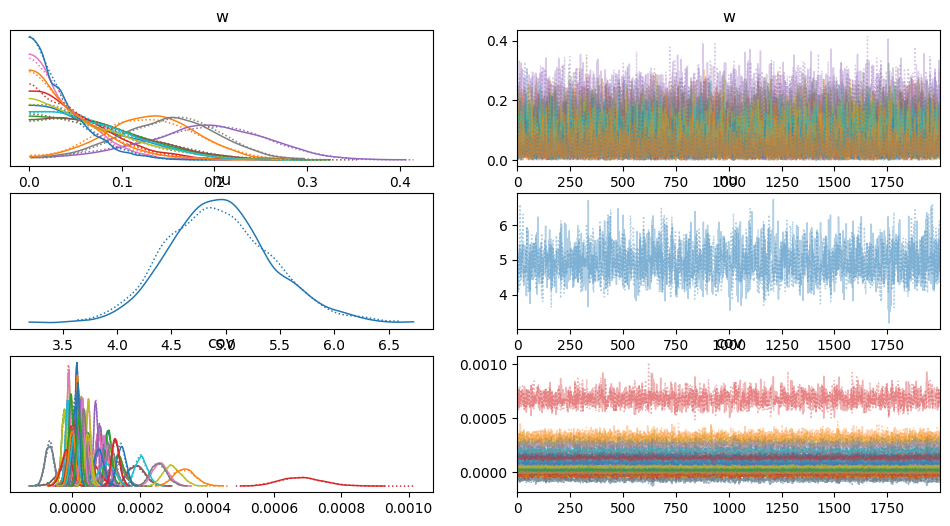

In [ ]:
az.plot_trace(trace_t,var_names=['w','nu','cov']);

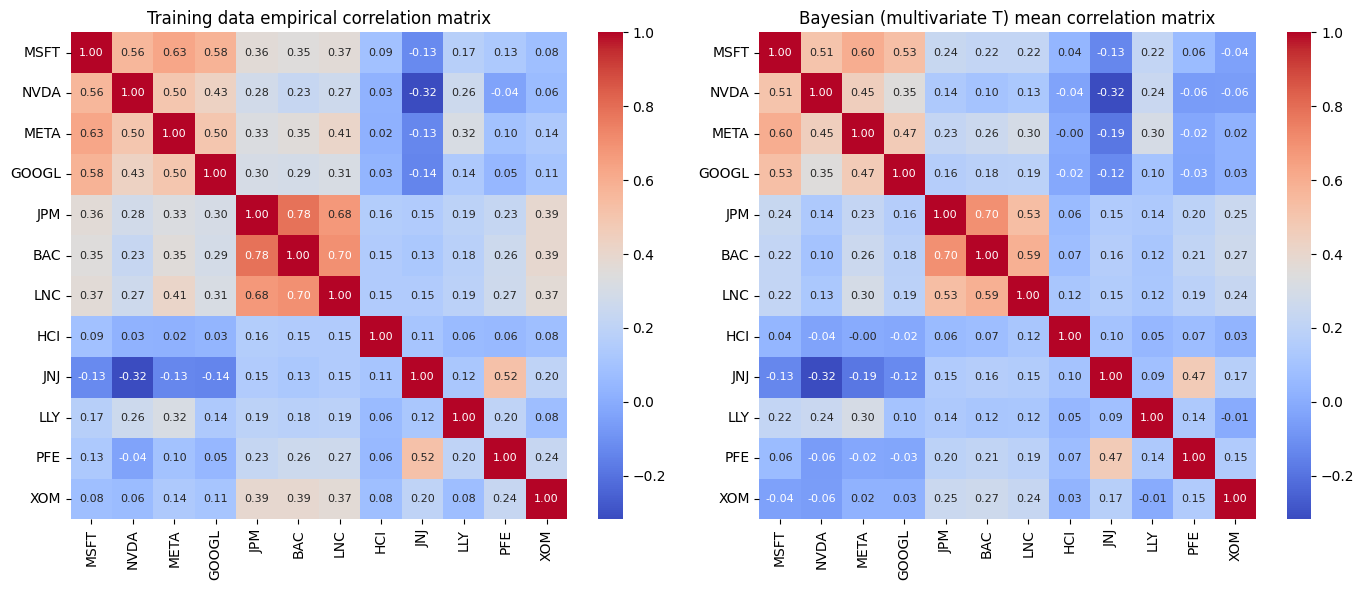

In [ ]:
# mean correlation matrix from the Bayesian model
corr_bayesian_mean = az.summary(trace_t, var_names=['corr'])['mean'].values.reshape(n_assets, n_assets)

# Convert to DataFrame for easier plotting with seaborn and to apply asset names
df_corr_bayesian = pd.DataFrame(corr_bayesian_mean, index=tickers, columns=tickers)

raw_corr_df = df_train.corr()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.heatmap(raw_corr_df, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title('Training data empirical correlation matrix')

plt.subplot(1, 2, 2)
sns.heatmap(df_corr_bayesian, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8})
plt.title('Bayesian (multivariate T) mean correlation matrix')
plt.tight_layout()
plt.show()

In [ ]:
# to derive the optimal portfolio weights based on the Bayesian model results
# extract posterior samples
w_samples = trace_t.posterior['w'].values.reshape(-1, n_assets)
sharpe_samples = trace_t.posterior['port_sharpe'].values.reshape(-1)

# normalize sample Sharpe ratios to create weights (Sharpe ratio can be negative) to sum to one
sharpe_normalized = sharpe_samples - sharpe_samples.min()  # shift to positive
sharpe_weights = sharpe_normalized / sharpe_normalized.sum()  # normalize so that weights sum to 1

# Compute Sharpe ratio weighted portfolio weights
w_optimal = (w_samples.T * sharpe_weights).sum(axis=1)

<Figure size 700x500 with 0 Axes>

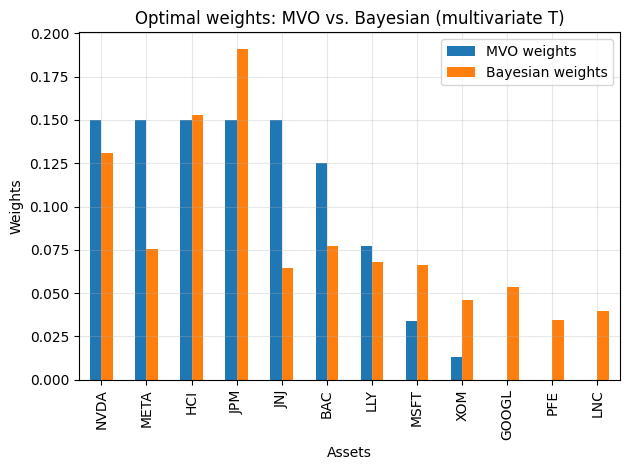

In [ ]:
mvo_weights = pd.Series(max_sharpe_weights, index=tickers, name='MVO weights')
bayesian_weights = pd.Series(w_optimal, index=tickers, name='Bayesian weights')

comparison_df = pd.DataFrame({'MVO weights': mvo_weights,'Bayesian weights': bayesian_weights})
comparison_df = comparison_df.sort_values(by='MVO weights', ascending=False)

# bar chart comparing the optimal weights
plt.figure(figsize=(7, 5))
comparison_df.plot(kind='bar', rot=90)
plt.title('Optimal weights: MVO vs. Bayesian (multivariate T)')
plt.xlabel('Assets')
plt.ylabel('Weights')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show();

Testing data performance of the Bayesian (multivariate T) Optimal portfolio
Test data performance of the Bayesian Optimal portfolio:

Average daily return: 0.089%
Daily volatility: 0.559%
Sharpe ratio: 12.260%
Maximum drawdown: -1.607%
VaR at 95%: -0.772%


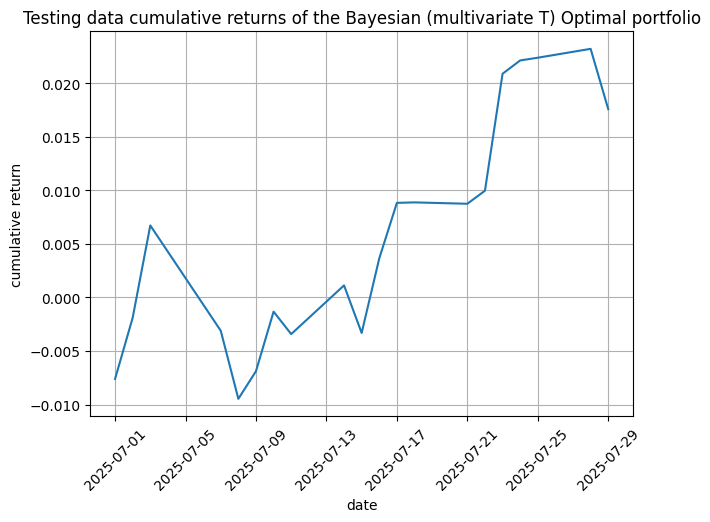

In [ ]:
# Testing data performance the Bayesian Optimal Portfolio
print("Testing data performance of the Bayesian (multivariate T) Optimal portfolio")

test_returns_bayesian = (df_test[tickers] @ w_optimal)
test_avg_ret_bayesian = test_returns_bayesian.mean()
test_vol_bayesian = test_returns_bayesian.std()
test_sharpe_bayesian = (test_avg_ret_bayesian - rf) / test_vol_bayesian
test_max_drawdown_bayesian = max_drawdown(test_returns_bayesian)
test_var_95_bayesian = historical_var(test_returns_bayesian, level=0.05)

print("Test data performance of the Bayesian Optimal portfolio:\n")
print(f"Average daily return: {test_avg_ret_bayesian:.3%}")
print(f"Daily volatility: {test_vol_bayesian:.3%}")
print(f"Sharpe ratio: {test_sharpe_bayesian:.3%}")
print(f"Maximum drawdown: {test_max_drawdown_bayesian:.3%}")
print(f"VaR at 95%: {test_var_95_bayesian:.3%}")

# plot cumulative returns
cumulative_rets_bayesian = (1 + test_returns_bayesian).cumprod() - 1
plt.figure(figsize=(7, 5))
plt.plot(cumulative_rets_bayesian)
plt.title('Testing data cumulative returns of the Bayesian (multivariate T) Optimal portfolio')
plt.xlabel('date')
plt.ylabel('cumulative return')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


###### Comparing the Testing data performance metrics from all above models

In [ ]:
performance_data = {'Metric': ['Average daily return', 'Daily volatility', 'Sharpe ratio', 'Maximum drawdown', 'VaR @ 95%']}

# Gather metrics for Step 1 MVO (Maximal Sharpe Ratio Portfolio)
performance_data['MVO'] = [test_avg_ret,test_vol,test_sharpe,test_max_drawdown,test_var_95]
performance_data['Ledoit-Wolf'] = [test_avg_ret_LW, test_vol_LW,test_sharpe_LW, test_max_drawdown_LW,test_var_95_LW]
performance_data['EPO with CPCV'] = [test_avg_ret_epo, test_vol_epo,test_sharpe_epo, test_max_drawdown_epo,test_var_95_epo]
performance_data['Bayesian Normal'] = [test_avg_ret_bayesian_normal, test_vol_bayesian_normal,test_sharpe_bayesian_normal, test_max_drawdown_bayesian_normal,test_var_95_bayesian_normal]
performance_data['Bayesian Student-T'] = [test_avg_ret_bayesian, test_vol_bayesian,test_sharpe_bayesian, test_max_drawdown_bayesian,test_var_95_bayesian]


performance_df = pd.DataFrame(performance_data)
for col in performance_df.columns[1:]:
    performance_df[col] = performance_df[col].apply(lambda x: f"{x:.3%}")

print("Comparing Testing data performance metrics")
display(performance_df)

Comparing Testing data performance metrics


,Metric,MVO,Ledoit-Wolf,EPO with CPCV,Bayesian Normal,Bayesian Student-T
0,Average daily return,0.076%,0.076%,0.077%,0.100%,0.089%
1,Daily volatility,0.611%,0.611%,0.609%,0.541%,0.559%
2,Sharpe ratio,9.115%,9.172%,9.294%,14.764%,12.260%
3,Maximum drawdown,-1.529%,-1.512%,-1.519%,-1.125%,-1.607%
4,VaR @ 95%,-0.842%,-0.843%,-0.828%,-0.901%,-0.772%


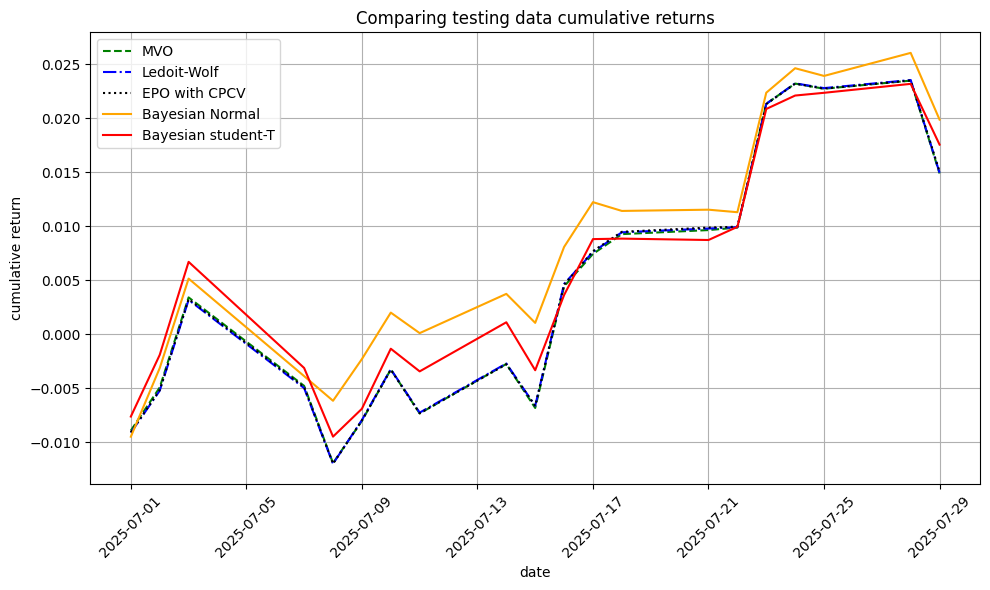

In [ ]:
plt.figure(figsize=(10, 6))
plt.title('Comparing testing data cumulative returns')
plt.xlabel('date')
plt.ylabel('cumulative return')
plt.grid(True)
plt.xticks(rotation=45)

plt.plot(cumulative_rets, label='MVO', color='green',linestyle = '--')
plt.plot(cumulative_rets_LW, label='Ledoit-Wolf',color='blue',linestyle = '-.')
plt.plot(cumulative_rets_epo, label='EPO with CPCV', color = 'black',linestyle = ':')
plt.plot(cumulative_rets_bayesian_normal, label='Bayesian Normal', color ='orange')
plt.plot(cumulative_rets_bayesian, label='Bayesian student-T', color ='red')
plt.legend()
plt.tight_layout()
plt.show()

#### Improvements using clustering

###### Hierarchical Risk Parity (HRP)

In [ ]:
def get_inverse_variance_weights(cov):
    iv = 1 / np.diag(cov)
    return iv / iv.sum()

def get_cluster_variance(cov, weights):
    return weights.T @ cov @ weights

def recursive_bisection(cov_matrix, indices, risk_budget=1):
    weights = pd.Series(1.0, index=indices)

    def split_and_allocate(indices):
        if len(indices) == 1:
            return  # base case

        mid = len(indices) // 2
        left = indices[:mid]
        right = indices[mid:]

        # bisect the covariances into left and right
        cov_left = cov_matrix.iloc[left, left]
        cov_right = cov_matrix.iloc[right, right]

        w_left = get_inverse_variance_weights(cov_left)
        w_right = get_inverse_variance_weights(cov_right)

        v_left = get_cluster_variance(cov_left, w_left)
        v_right = get_cluster_variance(cov_right, w_right)

        # Allocate cluster-level weights
        alpha_left = 1 - v_left / (v_left + v_right)
        alpha_right = 1 - alpha_left

        # Update global weights
        weights[left] *= alpha_left
        weights[right] *= alpha_right

        split_and_allocate(left)
        split_and_allocate(right)

    split_and_allocate(indices)

    return weights / weights.sum()

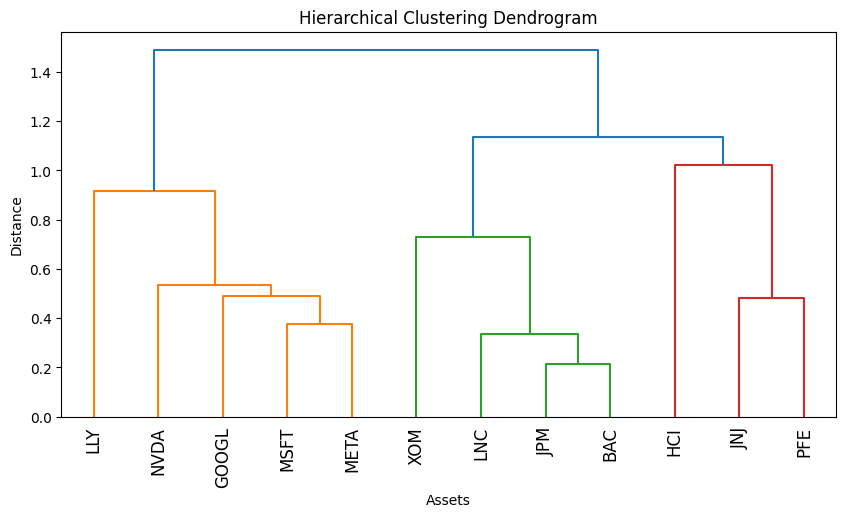

In [ ]:
distance_matrix = squareform(1 - corr_matrix_raw)
linkage_matrix = linkage(distance_matrix, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, labels=tickers, leaf_rotation=90)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Assets')
plt.ylabel('Distance')
plt.show()

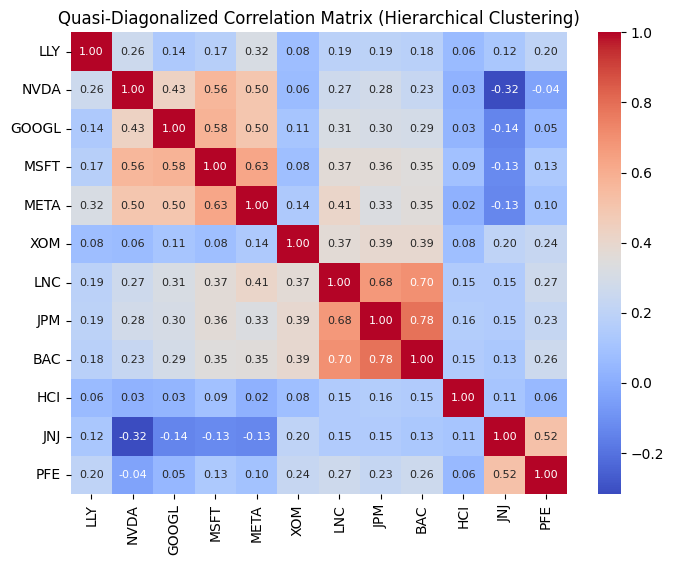

In [ ]:
order = leaves_list(linkage_matrix)
corr_quasi_diag = corr_matrix_raw.iloc[order, order]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_quasi_diag, annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 8})
plt.title('Quasi-Diagonalized Correlation Matrix (Hierarchical Clustering)')
plt.show()

In [ ]:
hrp_weights = recursive_bisection(corr_quasi_diag, order, 1)
assert np.isclose(hrp_weights.sum(), 1.0), f"Weights do not sum to 1.0, current sum: {hrp_weights.sum()}"

print(f"HRP weights sum: {hrp_weights.sum():.4f}")
hrp_weights.index = [tickers[i] for i in hrp_weights.index]

HRP weights sum: 1.0000


In [ ]:
test_returns_hrp = (df_test[tickers] @ hrp_weights)
test_avg_ret_hrp = test_returns_hrp.mean()
test_vol_hrp = test_returns_hrp.std()
test_sharpe_hrp = (test_avg_ret_hrp - rf) / test_vol_hrp
test_max_drawdown_hrp = max_drawdown(test_returns_hrp)
test_var_95_hrp = historical_var(test_returns_hrp, level=0.05)
cumulative_returns_hrp = (1 + test_returns_hrp).cumprod() - 1

performance_data['HRP'] = [test_avg_ret_hrp, test_vol_hrp, test_sharpe_hrp, test_max_drawdown_hrp, test_var_95_hrp]

###### Hierarchical Equal Risk Contribution (HERC)

In [ ]:
def find_optimal_clusters(linkage_matrix, max_k=10):

    n_assets = linkage_matrix.shape[0] + 1
    last_merges = linkage_matrix[-max_k:, 2]
    second_derivative = np.diff(np.diff(last_merges))

    if len(second_derivative) > 0:
        optimal_k = max_k - np.argmax(second_derivative) - 1
    else:
        optimal_k = min(3, n_assets)

    return max(2, optimal_k)


In [ ]:
def compute_portfolio_cdar(weights, returns, alpha=0.95):

    portfolio_returns = (returns * weights).sum(axis=1)

    # Compute drawdowns for portfolio
    cumulative_returns = (1 + portfolio_returns).cumprod()
    running_max = cumulative_returns.expanding().max()
    portfolio_drawdowns = (cumulative_returns - running_max) / running_max

    # Compute CDaR
    sorted_drawdowns = np.sort(portfolio_drawdowns.dropna().values)
    n_worst = int(len(sorted_drawdowns) * (1 - alpha))

    if n_worst > 0:
        worst_drawdowns = sorted_drawdowns[:n_worst]
        portfolio_cdar = -np.mean(worst_drawdowns)
    else:
        portfolio_cdar = -np.mean(sorted_drawdowns)

    return portfolio_cdar


def compute_cluster_cdar(returns, cluster_assets, alpha=0.95):

    n_assets = len(cluster_assets)
    if n_assets == 0:
        return 0

    # Equal weights within cluster
    weights = np.ones(n_assets) / n_assets

    # Get returns for cluster assets
    cluster_returns = returns.iloc[:, cluster_assets]
    portfolio_cdar = compute_portfolio_cdar(weights, cluster_returns, alpha)

    return portfolio_cdar

def compute_conditional_drawdown_at_risk(returns, alpha=0.95):

    # calc drawdowns
    cumulative_returns = (1 + returns).cumprod()
    running_max = cumulative_returns.expanding().max()
    drawdowns = (cumulative_returns - running_max) / running_max

    # compute CDaR (CDaR_α = -E[Drawdown | Drawdown ≤ VaR_α(Drawdown)])
    cdar_values = {}
    for asset in returns.columns:
        asset_drawdowns = drawdowns[asset].dropna()

        # most negative first
        sorted_drawdowns = np.sort(asset_drawdowns)

        # Calculate the threshold index for worst (1-alpha)% drawdowns
        n_worst = int(len(sorted_drawdowns) * (1 - alpha))

        if n_worst > 0:
            worst_drawdowns = sorted_drawdowns[:n_worst]
            cdar = -np.mean(worst_drawdowns)
        else:
            cdar = -np.mean(sorted_drawdowns)

        cdar_values[asset] = cdar

    return cdar_values

def plot_conditional_drawdown_at_risk(cdar_values_dict):

    cdar_series = pd.Series(cdar_values_dict).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    cdar_series.plot(kind='bar')
    plt.title('Conditional Drawdown at Risk (CDaR) per Asset')
    plt.xlabel('Assets')
    plt.ylabel('CDaR Value')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
def compute_risk_contributions(weights, returns, alpha=0.95):

    weights_vector = np.array(list(weights.values()))
    #CDaR
    portfolio_cdar = compute_portfolio_cdar(weights_vector, returns, alpha)

    # Compute marginal contributions using finite differences
    epsilon = 1e-6
    risk_contributions = np.zeros(len(weights_vector))

    for i in range(len(weights_vector)):
        # ammend weights i
        weights_perturbed = weights_vector.copy()
        weights_perturbed[i] += epsilon

        # Renormalize
        weights_perturbed /= np.sum(weights_perturbed)

        cdar_perturbed = compute_portfolio_cdar(weights_perturbed, returns, alpha)

        # Marginal contribution approximation
        marginal_contribution = (cdar_perturbed - portfolio_cdar) / epsilon
        risk_contributions[i] = weights_vector[i] * marginal_contribution

    # Normalize risk contributions to sum to portfolio CDaR
    risk_contributions = risk_contributions * (portfolio_cdar / np.sum(risk_contributions))

    return risk_contributions

In [ ]:
def compute_naive_cdar_parity_weights(returns, alpha=0.95):

    # Compute naive CDaR parity weights (inverse CDaR weighting)
    cdar_values = compute_conditional_drawdown_at_risk(returns, alpha)
    cdar_array = np.array([cdar_values[asset] for asset in returns.columns])

    cdar_array = np.maximum(cdar_array, 1e-8)

    weights = 1 / cdar_array
    return weights / np.sum(weights)

In [ ]:
def herc_weights_recursive(returns, cluster_assignments, current_cluster=None, alpha=0.95):

    n_assets = returns.shape[1]

    if current_cluster is None:
        # top-down starting point
        current_assets = list(range(n_assets))
    else:
        current_assets = [i for i, cluster in enumerate(cluster_assignments) if cluster == current_cluster]

    n_current_assets = len(current_assets)

    if n_current_assets <= 1:
        # Base case: single asset
        if n_current_assets == 1:
            return {current_assets[0]: 1.0}
        else:
            return {}

    # get sub clusters
    sub_clusters = np.unique([cluster_assignments[i] for i in current_assets])

    if len(sub_clusters) == 1:
        # use naive CDaR parity (w_gk)
        sub_returns = returns.iloc[:, current_assets]
        cdar_weights = compute_naive_cdar_parity_weights(sub_returns, alpha)
        return {current_assets[i]: cdar_weights[i] for i in range(len(current_assets))}

    # Calc CDaR for each sub-cluster
    cluster_cdar_values = {}
    for cluster in sub_clusters:
        cluster_assets = [i for i in current_assets if cluster_assignments[i] == cluster]
        cluster_cdar_values[cluster] = compute_cluster_cdar(returns, cluster_assets, alpha)

    # Allocate weights inversely proportional to cluster CDaR
    inverse_cdar = {cluster: 1/cdar for cluster, cdar in cluster_cdar_values.items()}
    total_inverse_cdar = sum(inverse_cdar.values())
    cluster_weights = {cluster: inv_cdar/total_inverse_cdar for cluster, inv_cdar in inverse_cdar.items()}

    # Recursively compute weights for each sub-cluster
    final_weights = {}
    for cluster, cluster_weight in cluster_weights.items():
        sub_weights = herc_weights_recursive(returns, cluster_assignments, cluster, alpha)
        # Scale sub-cluster weights by cluster weight
        for asset, weight in sub_weights.items():
            final_weights[asset] = weight * cluster_weight

    return final_weights

In [ ]:
def implement_herc_cdar(Z, returns, max_k=10, alpha=0.95):

    n_clusters = find_optimal_clusters(Z, max_k)
    print(f"Optimal number of clusters: {n_clusters}")

    cluster_assignments = fcluster(Z, n_clusters, criterion='maxclust')

    for cluster_id in np.unique(cluster_assignments):
        cluster_assets = [returns.columns[i] for i, c in enumerate(cluster_assignments) if c == cluster_id]
        print(f"Cluster {cluster_id}: {cluster_assets}")

    #  HERC weights recursively with CDaR
    weights_dict = herc_weights_recursive(returns, cluster_assignments, alpha=alpha)

    # create weight vector
    weights_vector = np.zeros(len(returns.columns))
    for asset_idx, weight in weights_dict.items():
        weights_vector[asset_idx] = weight

    weights_vector = weights_vector / np.sum(weights_vector)
    final_weights = dict(zip(range(len(returns.columns)), weights_vector))

    # CDaR risk contributions
    risk_contributions = compute_risk_contributions(final_weights, returns, alpha)
    portfolio_cdar = compute_portfolio_cdar(weights_vector, returns, alpha)

    return {
        'weights': final_weights,
        'risk_contributions': risk_contributions,
        'portfolio_cdar': portfolio_cdar,
        'optimal_k': n_clusters
    }

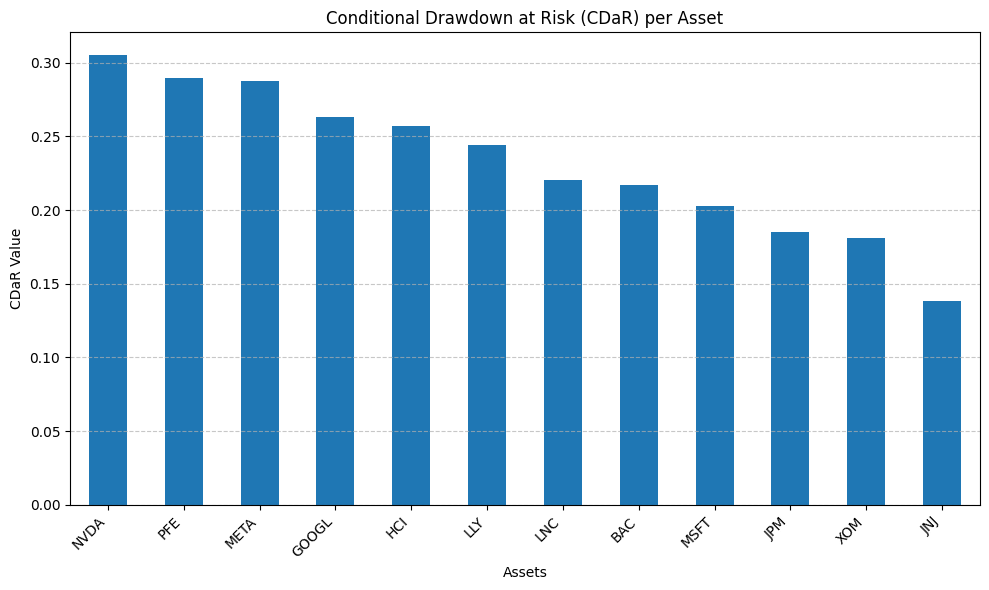

In [ ]:
cdar_values = compute_conditional_drawdown_at_risk(df_train)
plot_conditional_drawdown_at_risk(cdar_values)

In [ ]:
results = implement_herc_cdar(linkage_matrix, df_train,max_k=8, alpha=0.95)

# Display results
weights_herc_cdar = results['weights']
risk_contributions = results['risk_contributions']
portfolio_cdar = results['portfolio_cdar']
optimal_k = results['optimal_k']

assert np.isclose(sum(weights_herc_cdar.values()), 1.0), f"Weights do not sum to 1.0, current sum: {sum(weights_herc_cdar.values())}"

Optimal number of clusters: 2
Cluster 1: ['MSFT', 'NVDA', 'META', 'GOOGL', 'LLY']
Cluster 2: ['JPM', 'BAC', 'LNC', 'HCI', 'JNJ', 'PFE', 'XOM']


In [ ]:
print(f"\nOptimal number of clusters: {optimal_k}")
print(f"Portfolio CDaR: {portfolio_cdar:.4f}")

print("\nPortfolio Weights:")
for i, asset in enumerate(df_train.columns):
    print(f"{asset}: {weights_herc_cdar[i]:.4f} ({weights_herc_cdar[i]*100:.2f}%)")


Optimal number of clusters: 2
Portfolio CDaR: 0.1100

Portfolio Weights:
MSFT: 0.0918 (9.18%)
NVDA: 0.0610 (6.10%)
META: 0.0648 (6.48%)
GOOGL: 0.0708 (7.08%)
JPM: 0.0990 (9.90%)
BAC: 0.0844 (8.44%)
LNC: 0.0833 (8.33%)
HCI: 0.0713 (7.13%)
JNJ: 0.1326 (13.26%)
LLY: 0.0763 (7.63%)
PFE: 0.0634 (6.34%)
XOM: 0.1012 (10.12%)


###### Clustered Portfolio Results

In [ ]:
herc_weights_series = pd.Series(list(weights_herc_cdar.values()), index=df_train.columns)

test_returns_herc = (df_test[tickers] @ herc_weights_series)
test_avg_ret_herc = test_returns_herc.mean()
test_vol_herc = test_returns_herc.std()
test_sharpe_herc = (test_avg_ret_herc - rf) / test_vol_herc
test_max_drawdown_herc = max_drawdown(test_returns_herc)
test_var_95_herc = historical_var(test_returns_herc, level=0.05)
cumulative_returns_herc = (1 + test_returns_herc).cumprod() - 1
performance_data['HERC'] = [test_avg_ret_herc, test_vol_herc, test_sharpe_herc, test_max_drawdown_herc, test_var_95_herc]

In [ ]:
print("Comparing Testing data performance metrics")
display(performance_df)

Comparing Testing data performance metrics


,Metric,MVO,Ledoit-Wolf,EPO with CPCV,Bayesian Normal,Bayesian Student-T,HRP,HERC (CPCV),HERC,HERC & CPCV,HERC_CPCV
0,Average daily return,0.076%,0.076%,0.077%,0.100%,0.089%,0.104%,0.097%,0.144%,0.097%,0.097%
1,Daily volatility,0.611%,0.611%,0.609%,0.541%,0.559%,0.534%,1.015%,0.534%,1.015%,1.015%
2,Sharpe ratio,9.115%,9.172%,9.294%,14.764%,12.260%,15.750%,7.775%,23.186%,7.775%,7.775%
3,Maximum drawdown,-1.529%,-1.512%,-1.519%,-1.125%,-1.607%,-1.015%,-10.412%,-1.108%,-10.412%,-10.412%
4,VaR @ 95%,-0.842%,-0.843%,-0.828%,-0.901%,-0.772%,-0.860%,-1.468%,-0.878%,-1.468%,-1.468%


<Figure size 1000x600 with 0 Axes>

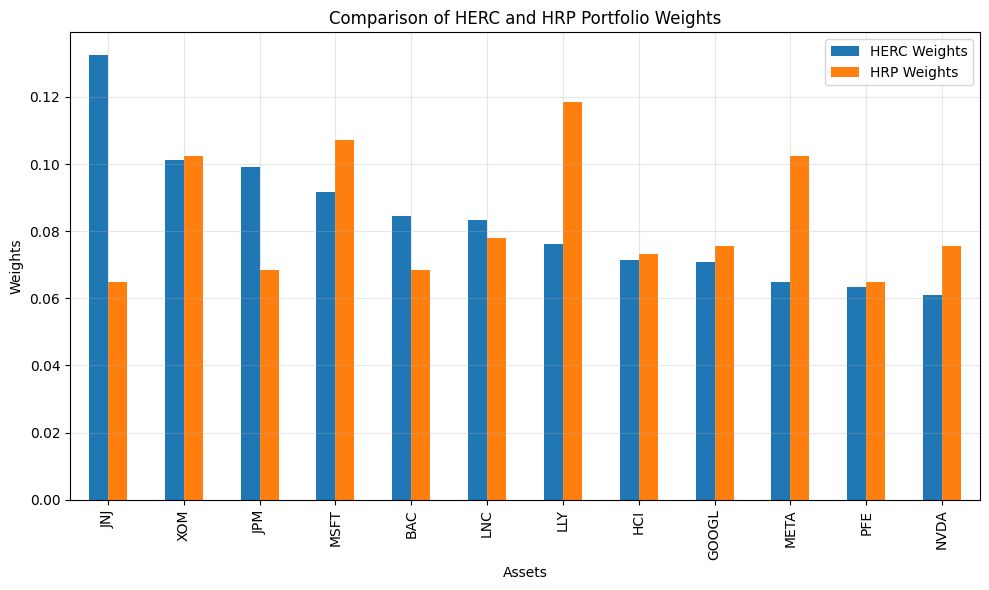

In [ ]:
herc_weights_series = pd.Series(list(weights_herc_cdar.values()), index=df_train.columns)
hrp_weights.index = df_train.columns[order]

# Create a DataFrame for comparison
comparison_weights_df = pd.DataFrame({
    'HERC Weights': herc_weights_series,
    'HRP Weights': hrp_weights
})

comparison_weights_df = comparison_weights_df.sort_values(by='HERC Weights', ascending=False)
plt.figure(figsize=(10, 6))
comparison_weights_df.plot(kind='bar', rot=90, figsize=(10, 6))
plt.title('Comparison of HERC and HRP Portfolio Weights')
plt.xlabel('Assets')
plt.ylabel('Weights')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

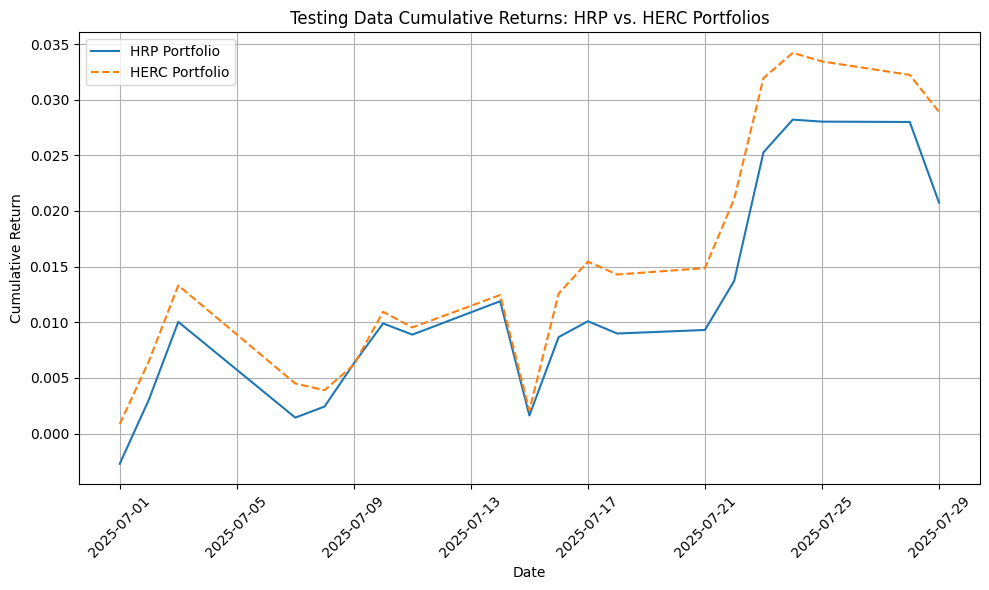

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(cumulative_returns_hrp, label='HRP Portfolio', linestyle='-', marker='')
plt.plot(cumulative_returns_herc, label='HERC Portfolio', linestyle='--', marker='')

plt.title('Testing Data Cumulative Returns: HRP vs. HERC Portfolios')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

#### Improvements using backtesting

##### Efficient Portfolio Optimization (Pedersen et al.) with simplified CPCV (Combinatory Purged Cross Validation)

In [ ]:
# simplified Combinatory Purged Cross Validation (CPCV) function
def cpcv_splits(df, n_folds=5, n_test_folds=2):
    n_obs = len(df)
    fold_size = n_obs // n_folds
    folds = [(i * fold_size, i * fold_size + fold_size if i < n_folds - 1 else n_obs) for i in range(n_folds)]

    df_list = []
    for test_fold_ids in combinations(range(n_folds), n_test_folds):
        test_idx = [idx for fold_id in test_fold_ids for idx in range(folds[fold_id][0], folds[fold_id][1])]
        train_fold_ids = set(range(n_folds)) - set(test_fold_ids)
        train_idx = [idx for fold_id in train_fold_ids for idx in range(folds[fold_id][0], folds[fold_id][1])]
        df_list.append({'train': df.iloc[train_idx], 'test':df.iloc[test_idx]})

    return df_list


In [ ]:
df_cpcv_list=cpcv_splits(df_train)

In [ ]:
cpcv_mvo_performance_metrics = {
    'avg_ret': [],
    'vol': [],
    'sharpe': [],
    'max_drawdown': [],
    'var_95': []
}

all_mvo_weights_per_fold = []

for fold_id, fold in enumerate(df_cpcv_list):

    df_train_fold = fold['train']
    df_test_fold = fold['test']

    mu_raw_fold = df_train_fold.mean().values
    cov_raw_fold = df_train_fold.cov().values

    port_weights, port_rets, port_vols, port_sharpes = func_mvo(mu_raw_fold, cov_raw_fold, rf, n_assets)

    if len(port_sharpes) > 0:
        max_sharpe_idx = np.argmax(port_sharpes)
        max_sharpe_weights_fold = port_weights[max_sharpe_idx]
    else:
        # Default to zero weights if no valid portfolio is found
        max_sharpe_weights_fold = np.zeros(n_assets)

    all_mvo_weights_per_fold.append(max_sharpe_weights_fold)

    # fold results
    test_returns_mvo_fold = (df_test_fold[tickers] @ max_sharpe_weights_fold)
    test_avg_ret_mvo_fold = test_returns_mvo_fold.mean()
    test_vol_mvo_fold = test_returns_mvo_fold.std()
    test_sharpe_mvo_fold = (test_avg_ret_mvo_fold - rf) / test_vol_mvo_fold if test_vol_mvo_fold != 0 else -np.inf
    test_max_drawdown_mvo_fold = max_drawdown(test_returns_mvo_fold)
    test_var_95_mvo_fold = historical_var(test_returns_mvo_fold, level=0.05)

    cpcv_mvo_performance_metrics['avg_ret'].append(test_avg_ret_mvo_fold)
    cpcv_mvo_performance_metrics['vol'].append(test_vol_mvo_fold)
    cpcv_mvo_performance_metrics['sharpe'].append(test_sharpe_mvo_fold)
    cpcv_mvo_performance_metrics['max_drawdown'].append(test_max_drawdown_mvo_fold)
    cpcv_mvo_performance_metrics['var_95'].append(test_var_95_mvo_fold)

In [ ]:
# Aggregate weights across folds
aggregated_mvo_weights = np.mean(all_mvo_weights_per_fold, axis=0)
aggregated_mvo_weights_series = pd.Series(aggregated_mvo_weights, index=tickers)

print("\nAggregated MVO Weights across folds:")
print(aggregated_mvo_weights_series)
assert np.isclose(aggregated_mvo_weights_series.sum(), 1.0), f"Aggregated MVO weights do not sum to 1.0, current sum: {aggregated_mvo_weights_series.sum()}"

avg_cpcv_mvo_avg_ret = np.mean(cpcv_mvo_performance_metrics['avg_ret'])
avg_cpcv_mvo_vol = np.mean(cpcv_mvo_performance_metrics['vol'])
avg_cpcv_mvo_sharpe = np.mean(cpcv_mvo_performance_metrics['sharpe'])
avg_cpcv_mvo_max_drawdown = np.mean(cpcv_mvo_performance_metrics['max_drawdown'])
avg_cpcv_mvo_var_95 = np.mean(cpcv_mvo_performance_metrics['var_95'])

performance_data['MVO_CPCV'] = [
    avg_cpcv_mvo_avg_ret,
    avg_cpcv_mvo_vol,
    avg_cpcv_mvo_sharpe,
    avg_cpcv_mvo_max_drawdown,
    avg_cpcv_mvo_var_95
]

performance_df = pd.DataFrame(performance_data)
for col in performance_df.columns[1:]:
    performance_df[col] = performance_df[col].apply(lambda x: f"{x:.3%}")


Aggregated MVO Weights across folds:
MSFT     0.083562
NVDA     0.139724
META     0.138551
GOOGL    0.007278
JPM      0.135000
BAC      0.074005
LNC      0.013912
HCI      0.142631
JNJ      0.097967
LLY      0.066074
PFE      0.036205
XOM      0.065093
dtype: float64


In [ ]:
print("\nComparing Testing data performance metrics with MVO_CPCV:")
display(performance_df)


Comparing Testing data performance metrics with MVO_CPCV:


,Metric,MVO,Ledoit-Wolf,EPO with CPCV,Bayesian Normal,Bayesian Student-T,HRP,HERC,HERC_CPCV,HRP_CPCV,MVO_CPCV
0,Average daily return,0.076%,0.076%,0.077%,0.100%,0.089%,0.104%,0.144%,0.097%,0.114%,0.117%
1,Daily volatility,0.611%,0.611%,0.609%,0.541%,0.559%,0.534%,0.534%,1.015%,1.091%,1.206%
2,Sharpe ratio,9.115%,9.172%,9.294%,14.764%,12.260%,15.750%,23.186%,7.775%,8.705%,8.177%
3,Maximum drawdown,-1.529%,-1.512%,-1.519%,-1.125%,-1.607%,-1.015%,-1.108%,-10.412%,-11.128%,-12.415%
4,VaR @ 95%,-0.842%,-0.843%,-0.828%,-0.901%,-0.772%,-0.860%,-0.878%,-1.468%,-1.532%,-1.822%


##### HRP-CPCV Combination

In [ ]:
cpcv_hrp_performance_metrics = {
    'avg_ret': [],
    'vol': [],
    'sharpe': [],
    'max_drawdown': [],
    'var_95': []
}

all_hrp_weights_per_fold = []

for fold_id, fold in enumerate(df_cpcv_list):

    df_train_fold = fold['train']
    df_test_fold = fold['test']

    # cluster each training fold
    corr_matrix_raw_fold = df_train_fold.corr()
    distance_matrix_fold = squareform(1 - corr_matrix_raw_fold)
    linkage_matrix_fold = linkage(distance_matrix_fold, method='ward')

    order_fold = leaves_list(linkage_matrix_fold)
    corr_quasi_diag = corr_matrix_raw_fold.iloc[order_fold, order_fold]
    hrp_weights = recursive_bisection(corr_quasi_diag, order_fold, 1)
    hrp_weights.index = [tickers[i] for i in hrp_weights.index]

    all_hrp_weights_per_fold.append(hrp_weights.values)

    # fold results
    test_returns_hrp_fold = (df_test_fold[tickers] @ hrp_weights)
    test_avg_ret_hrp_fold = test_returns_hrp_fold.mean()
    test_vol_hrp_fold = test_returns_hrp_fold.std()
    test_sharpe_hrp_fold = (test_avg_ret_hrp_fold - rf) / test_vol_hrp_fold
    test_max_drawdown_hrp_fold = max_drawdown(test_returns_hrp_fold)
    test_var_95_hrp_fold = historical_var(test_returns_hrp_fold, level=0.05)

    cpcv_hrp_performance_metrics['avg_ret'].append(test_avg_ret_hrp_fold)
    cpcv_hrp_performance_metrics['vol'].append(test_vol_hrp_fold)
    cpcv_hrp_performance_metrics['sharpe'].append(test_sharpe_hrp_fold)
    cpcv_hrp_performance_metrics['max_drawdown'].append(test_max_drawdown_hrp_fold)
    cpcv_hrp_performance_metrics['var_95'].append(test_var_95_hrp_fold)

In [ ]:
aggregated_hrp_weights = np.mean(all_hrp_weights_per_fold, axis=0)
aggregated_hrp_weights_series = pd.Series(aggregated_hrp_weights, index=tickers)

print("Aggregated HRP Weights across folds:")
print(aggregated_hrp_weights_series)
assert np.isclose(aggregated_hrp_weights_series.sum(), 1.0), f"Aggregated HRP weights do not sum to 1.0, current sum: {aggregated_hrp_weights_series.sum()}"

Aggregated HRP Weights across folds:
MSFT     0.083620
NVDA     0.057107
META     0.057107
GOOGL    0.100898
JPM      0.079012
BAC      0.079012
LNC      0.105529
HCI      0.083105
JNJ      0.083105
LLY      0.098474
PFE      0.086515
XOM      0.086515
dtype: float64


In [ ]:
# aggregate results
avg_cpcv_hrp_avg_ret = np.mean(cpcv_hrp_performance_metrics['avg_ret'])
avg_cpcv_hrp_vol = np.mean(cpcv_hrp_performance_metrics['vol'])
avg_cpcv_hrp_sharpe = np.mean(cpcv_hrp_performance_metrics['sharpe'])
avg_cpcv_hrp_max_drawdown = np.mean(cpcv_hrp_performance_metrics['max_drawdown'])
avg_cpcv_hrp_var_95 = np.mean(cpcv_hrp_performance_metrics['var_95'])

performance_data['HRP_CPCV'] = [
    avg_cpcv_hrp_avg_ret,
    avg_cpcv_hrp_vol,
    avg_cpcv_hrp_sharpe,
    avg_cpcv_hrp_max_drawdown,
    avg_cpcv_hrp_var_95
]

##### HERC-CPCV Combination

In [ ]:
cpcv_herc_performance_metrics = {
    'avg_ret': [],
    'vol': [],
    'sharpe': [],
    'max_drawdown': [],
    'var_95': []
}

all_herc_weights_per_fold = []

for fold_id, fold in enumerate(df_cpcv_list):
    print(f"\nfold nummber: {fold_id}")

    df_train_fold = fold['train']
    df_test_fold = fold['test']

    # cluster each training fold
    corr_matrix_raw_fold = df_train_fold.corr()
    distance_matrix_fold = squareform(1 - corr_matrix_raw_fold)
    linkage_matrix_fold = linkage(distance_matrix_fold, method='ward')

    # calc HERC
    results_herc_fold = implement_herc_cdar(linkage_matrix_fold, df_train_fold, max_k=8, alpha=0.95)
    herc_weights_fold = results_herc_fold['weights']

    herc_weights_series_fold = pd.Series(list(herc_weights_fold.values()), index=df_train_fold.columns)
    all_herc_weights_per_fold.append(herc_weights_series_fold.values)

    # Test performance on the testing fold
    test_returns_herc_fold = (df_test_fold[tickers] @ herc_weights_series_fold)
    test_avg_ret_herc_fold = test_returns_herc_fold.mean()
    test_vol_herc_fold = test_returns_herc_fold.std()
    test_sharpe_herc_fold = (test_avg_ret_herc_fold - rf) / test_vol_herc_fold
    test_max_drawdown_herc_fold = max_drawdown(test_returns_herc_fold)
    test_var_95_herc_fold = historical_var(test_returns_herc_fold, level=0.05)

    # Store performance metrics
    cpcv_herc_performance_metrics['avg_ret'].append(test_avg_ret_herc_fold)
    cpcv_herc_performance_metrics['vol'].append(test_vol_herc_fold)
    cpcv_herc_performance_metrics['sharpe'].append(test_sharpe_herc_fold)
    cpcv_herc_performance_metrics['max_drawdown'].append(test_max_drawdown_herc_fold)
    cpcv_herc_performance_metrics['var_95'].append(test_var_95_herc_fold)


fold nummber: 0
Optimal number of clusters: 2
Cluster 1: ['JNJ', 'LLY', 'PFE']
Cluster 2: ['MSFT', 'NVDA', 'META', 'GOOGL', 'JPM', 'BAC', 'LNC', 'HCI', 'XOM']

fold nummber: 1
Optimal number of clusters: 2
Cluster 1: ['MSFT', 'NVDA', 'META', 'GOOGL']
Cluster 2: ['JPM', 'BAC', 'LNC', 'HCI', 'JNJ', 'LLY', 'PFE', 'XOM']

fold nummber: 2
Optimal number of clusters: 6
Cluster 1: ['JNJ', 'PFE']
Cluster 2: ['LLY']
Cluster 3: ['MSFT', 'NVDA', 'META', 'GOOGL']
Cluster 4: ['JPM', 'BAC', 'LNC']
Cluster 5: ['XOM']
Cluster 6: ['HCI']

fold nummber: 3
Optimal number of clusters: 2
Cluster 1: ['MSFT', 'NVDA', 'META', 'GOOGL', 'LLY']
Cluster 2: ['JPM', 'BAC', 'LNC', 'HCI', 'JNJ', 'PFE', 'XOM']

fold nummber: 4
Optimal number of clusters: 2
Cluster 1: ['HCI', 'JNJ', 'LLY', 'PFE']
Cluster 2: ['MSFT', 'NVDA', 'META', 'GOOGL', 'JPM', 'BAC', 'LNC', 'XOM']

fold nummber: 5
Optimal number of clusters: 2
Cluster 1: ['HCI', 'JNJ', 'LLY', 'PFE']
Cluster 2: ['MSFT', 'NVDA', 'META', 'GOOGL', 'JPM', 'BAC', 'LNC',

In [ ]:
aggregated_herc_weights = np.mean(all_herc_weights_per_fold, axis=0)
aggregated_herc_weights_series = pd.Series(aggregated_herc_weights, index=tickers)

print("Aggregated HERC Weights across folds:")
print(aggregated_herc_weights_series)
assert np.isclose(aggregated_herc_weights_series.sum(), 1.0), f"Aggregated HERC weights do not sum to 1.0, current sum: {aggregated_herc_weights_series.sum()}"

Aggregated HERC Weights across folds:
MSFT     0.082006
NVDA     0.046110
META     0.067887
GOOGL    0.063145
JPM      0.097602
BAC      0.067146
LNC      0.060533
HCI      0.111916
JNJ      0.131768
LLY      0.091579
PFE      0.082173
XOM      0.098135
dtype: float64


In [ ]:
# aggregate results
avg_cpcv_herc_avg_ret = np.mean(cpcv_herc_performance_metrics['avg_ret'])
avg_cpcv_herc_vol = np.mean(cpcv_herc_performance_metrics['vol'])
avg_cpcv_herc_sharpe = np.mean(cpcv_herc_performance_metrics['sharpe'])
avg_cpcv_herc_max_drawdown = np.mean(cpcv_herc_performance_metrics['max_drawdown'])
avg_cpcv_herc_var_95 = np.mean(cpcv_herc_performance_metrics['var_95'])

performance_data['HERC_CPCV'] = [
    avg_cpcv_herc_avg_ret,
    avg_cpcv_herc_vol,
    avg_cpcv_herc_sharpe,
    avg_cpcv_herc_max_drawdown,
    avg_cpcv_herc_var_95
]

performance_df = pd.DataFrame(performance_data)
for col in performance_df.columns[1:]:
    performance_df[col] = performance_df[col].apply(lambda x: f"{x:.3%}")

print("Comparing Testing data performance metrics")
display(performance_df.T)

Comparing Testing data performance metrics


,0,1,2,3,4
Metric,Average daily return,Daily volatility,Sharpe ratio,Maximum drawdown,VaR @ 95%
HRP,0.104%,0.534%,15.750%,-1.015%,-0.860%
HERC,0.144%,0.534%,23.186%,-1.108%,-0.878%
HRP_CPCV,0.114%,1.091%,8.705%,-11.128%,-1.532%
HERC_CPCV,0.097%,1.015%,7.775%,-10.412%,-1.468%


##### Optimal Combination

###### ? + HRP + CPCV